In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/arxiv_data_210930-054931.csv")
df.head()

,terms,titles,abstracts
0,['cs.LG'],Multi-Level Attention Pooling for Graph Neural...,Graph neural networks (GNNs) have been widely ...
1,"['cs.LG', 'cs.AI']",Decision Forests vs. Deep Networks: Conceptual...,Deep networks and decision forests (such as ra...
2,"['cs.LG', 'cs.CR', 'stat.ML']",Power up! Robust Graph Convolutional Network v...,Graph convolutional networks (GCNs) are powerf...
3,"['cs.LG', 'cs.CR']",Releasing Graph Neural Networks with Different...,With the increasing popularity of Graph Neural...
4,['cs.LG'],Recurrence-Aware Long-Term Cognitive Network f...,Machine learning solutions for pattern classif...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56181 entries, 0 to 56180
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   terms      56181 non-null  object
 1   titles     56181 non-null  object
 2   abstracts  56181 non-null  object
dtypes: object(3)
memory usage: 1.3+ MB


In [ ]:
df['terms'].value_counts()

,count
terms,
['cs.CV'],18719
"['cs.LG', 'stat.ML']",5431
['cs.LG'],2871
"['cs.CV', 'cs.LG']",2170
"['cs.LG', 'cs.AI']",1783
...,...
"['cs.LG', 'cs.HC', 'cs.SI', 'stat.ML']",1
"['cs.LG', 'cs.PF', 'cs.PL', 'stat.ML']",1
"['stat.ML', 'cs.LG', 'cs.NA', 'math.NA', 'math.OC', '62H30, 68T10, 68Q87, 91C20']",1


In [ ]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (56181, 3)

Dtypes:
 terms        object
titles       object
abstracts    object
dtype: object

Missing Values:
 terms        0
titles       0
abstracts    0
dtype: int64

Duplicate Rows: 15054


In [ ]:
df

,terms,titles,abstracts
0,['cs.LG'],Multi-Level Attention Pooling for Graph Neural...,Graph neural networks (GNNs) have been widely ...
1,"['cs.LG', 'cs.AI']",Decision Forests vs. Deep Networks: Conceptual...,Deep networks and decision forests (such as ra...
2,"['cs.LG', 'cs.CR', 'stat.ML']",Power up! Robust Graph Convolutional Network v...,Graph convolutional networks (GCNs) are powerf...
3,"['cs.LG', 'cs.CR']",Releasing Graph Neural Networks with Different...,With the increasing popularity of Graph Neural...
4,['cs.LG'],Recurrence-Aware Long-Term Cognitive Network f...,Machine learning solutions for pattern classif...
...,...,...,...
56176,"['cs.CV', 'cs.IR']",Mining Spatio-temporal Data on Industrializati...,Despite the growing availability of big data i...
56177,"['cs.LG', 'cs.AI', 'cs.CL', 'I.2.6; I.2.7']",Wav2Letter: an End-to-End ConvNet-based Speech...,This paper presents a simple end-to-end model ...
56178,['cs.LG'],Deep Reinforcement Learning with Double Q-lear...,The popular Q-learning algorithm is known to o...
56179,"['stat.ML', 'cs.LG', 'math.OC']",Generalized Low Rank Models,Principal components analysis (PCA) is a well-...


In [ ]:
import ast

# terms column is stored as a string like "['cs.LG', 'cs.AI']"
# Convert string → actual list
df['terms_list'] = df['terms'].apply(ast.literal_eval)

# How many papers have multiple labels?
df['num_labels'] = df['terms_list'].apply(len)

print("Label count distribution:")
print(df['num_labels'].value_counts().sort_index())

print(f"\nSingle-label papers : {(df['num_labels'] == 1).sum():,}")
print(f"Multi-label papers  : {(df['num_labels'] > 1).sum():,}")

# All unique arXiv category codes in the dataset
all_terms = [term for sublist in df['terms_list'] for term in sublist]
unique_terms = pd.Series(all_terms).value_counts()
print(f"\nTotal unique category codes: {len(unique_terms)}")
print("\nTop 20 category codes:")
print(unique_terms.head(20))

Label count distribution:
num_labels
1     21862
2     17867
3     11299
4      3711
5      1138
6       243
7        50
8         8
9         2
11        1
Name: count, dtype: int64

Single-label papers : 21,862
Multi-label papers  : 34,319

Total unique category codes: 1177

Top 20 category codes:
cs.CV      33433
cs.LG      30939
stat.ML    16570
cs.AI       8390
eess.IV     2647
cs.RO       2054
cs.CL       1659
cs.GR       1614
cs.NE       1378
cs.CR        739
math.OC      724
cs.SI        684
eess.SP      658
cs.MM        598
cs.SY        479
cs.IR        469
cs.HC        419
cs.MA        385
eess.SY      376
cs.IT        331
Name: count, dtype: int64


In [ ]:
df['abstract_len'] = df['abstracts'].astype(str).apply(lambda x: len(x.split()))
df['title_len']    = df['titles'].astype(str).apply(lambda x: len(x.split()))

print("Abstract word count stats:")
print(df['abstract_len'].describe())

print("\nTitle word count stats:")
print(df['title_len'].describe())

Abstract word count stats:
count    56181.000000
mean       172.804115
std         45.616158
min          5.000000
25%        141.000000
50%        171.000000
75%        202.000000
max        498.000000
Name: abstract_len, dtype: float64

Title word count stats:
count    56181.000000
mean         8.911607
std          3.025232
min          1.000000
25%          7.000000
50%          9.000000
75%         11.000000
max         30.000000
Name: title_len, dtype: float64


In [ ]:
print(f"Before dedup: {df.shape[0]:,} rows")

# Drop duplicates based on original string columns only (before any list conversion)
df = df.drop_duplicates(subset=['terms', 'titles', 'abstracts']).reset_index(drop=True)

print(f"After dedup : {df.shape[0]:,} rows")
print(f"Removed     : {56181 - len(df):,} duplicate rows")

Before dedup: 56,181 rows
After dedup : 41,127 rows
Removed     : 15,054 duplicate rows


In [ ]:
df

,terms,titles,abstracts,terms_list,num_labels,abstract_len,title_len
0,['cs.LG'],Multi-Level Attention Pooling for Graph Neural...,Graph neural networks (GNNs) have been widely ...,[cs.LG],1,247,13
1,"['cs.LG', 'cs.AI']",Decision Forests vs. Deep Networks: Conceptual...,Deep networks and decision forests (such as ra...,"[cs.LG, cs.AI]",2,234,14
2,"['cs.LG', 'cs.CR', 'stat.ML']",Power up! Robust Graph Convolutional Network v...,Graph convolutional networks (GCNs) are powerf...,"[cs.LG, cs.CR, stat.ML]",3,117,9
3,"['cs.LG', 'cs.CR']",Releasing Graph Neural Networks with Different...,With the increasing popularity of Graph Neural...,"[cs.LG, cs.CR]",2,216,8
4,['cs.LG'],Recurrence-Aware Long-Term Cognitive Network f...,Machine learning solutions for pattern classif...,[cs.LG],1,197,8
...,...,...,...,...,...,...,...
41122,['stat.ML'],An experimental study of graph-based semi-supe...,The volume of data generated by internet and s...,[stat.ML],1,214,11
41123,"['stat.ML', 'cs.LG']",Bayesian Differential Privacy through Posterio...,Differential privacy formalises privacy-preser...,"[stat.ML, cs.LG]",2,186,6
41124,"['cs.CV', 'cs.IR']",Mining Spatio-temporal Data on Industrializati...,Despite the growing availability of big data i...,"[cs.CV, cs.IR]",2,163,8
41125,"['cs.LG', 'cs.AI', 'cs.CL', 'I.2.6; I.2.7']",Wav2Letter: an End-to-End ConvNet-based Speech...,This paper presents a simple end-to-end model ...,"[cs.LG, cs.AI, cs.CL, I.2.6; I.2.7]",4,81,7


In [ ]:
import re
import ast

def clean_text(text):
    text = str(text)
    text = re.sub(r'\s+', ' ', text)          # normalize whitespace
    text = re.sub(r'[^\x00-\x7F]+', ' ', text) # remove non-ASCII
    text = re.sub(r'\$.*?\$', '', text)         # remove LaTeX math $...$
    text = re.sub(r'\\[a-zA-Z]+', '', text)     # remove LaTeX commands \cmd
    text = re.sub(r'[^\w\s\.\,\-]', ' ', text)  # keep words, spaces, basic punct
    text = re.sub(r'\s+', ' ', text).strip()    # final whitespace cleanup
    return text

# Apply cleaning
df['clean_abstract'] = df['abstracts'].apply(clean_text)
df['clean_title']    = df['titles'].apply(clean_text)

# Combine title + abstract (used as model input)
df['combined_text'] = df['clean_title'] + ' ' + df['clean_abstract']

print("✅ Text cleaning done!")
print("\nOriginal abstract sample:")
print(df['abstracts'].iloc[0][:200])
print("\nCleaned abstract sample:")
print(df['clean_abstract'].iloc[0][:200])

✅ Text cleaning done!

Original abstract sample:
Graph neural networks (GNNs) have been widely used to learn vector
representation of graph-structured data and achieved better task performance
than conventional methods. The foundation of GNNs is the

Cleaned abstract sample:
Graph neural networks GNNs have been widely used to learn vector representation of graph-structured data and achieved better task performance than conventional methods. The foundation of GNNs is the m


In [ ]:
df.columns

Index(['terms', 'titles', 'abstracts', 'terms_list', 'num_labels',
       'abstract_len', 'title_len', 'clean_abstract', 'clean_title',
       'combined_text'],
      dtype='object')

In [ ]:
import nltk
import pandas as pd
import numpy as np

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
df["word_tokens"] = df["combined_text"].apply(word_tokenize)

print(df["word_tokens"].head())

0    [Multi-Level, Attention, Pooling, for, Graph, ...
1    [Decision, Forests, vs, ., Deep, Networks, Con...
2    [Power, up, Robust, Graph, Convolutional, Netw...
3    [Releasing, Graph, Neural, Networks, with, Dif...
4    [Recurrence-Aware, Long-Term, Cognitive, Netwo...
Name: word_tokens, dtype: object


In [ ]:
df["sentence_tokens"] = df["combined_text"].apply(sent_tokenize)

print(df["sentence_tokens"].head())

0    [Multi-Level Attention Pooling for Graph Neura...
1    [Decision Forests vs., Deep Networks Conceptua...
2    [Power up Robust Graph Convolutional Network v...
3    [Releasing Graph Neural Networks with Differen...
4    [Recurrence-Aware Long-Term Cognitive Network ...
Name: sentence_tokens, dtype: object


In [ ]:
stop_words = set(stopwords.words("english"))

df["tokens_no_stopwords"] = df["word_tokens"].apply(
    lambda tokens: [word for word in tokens if word.lower() not in stop_words]
)

print(df["tokens_no_stopwords"].head())

0    [Multi-Level, Attention, Pooling, Graph, Neura...
1    [Decision, Forests, vs, ., Deep, Networks, Con...
2    [Power, Robust, Graph, Convolutional, Network,...
3    [Releasing, Graph, Neural, Networks, Different...
4    [Recurrence-Aware, Long-Term, Cognitive, Netwo...
Name: tokens_no_stopwords, dtype: object


In [ ]:
lemmatizer = WordNetLemmatizer()

df["lemmatized_tokens"] = df["tokens_no_stopwords"].apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)

print(df["lemmatized_tokens"].head())

0    [Multi-Level, Attention, Pooling, Graph, Neura...
1    [Decision, Forests, v, ., Deep, Networks, Conc...
2    [Power, Robust, Graph, Convolutional, Network,...
3    [Releasing, Graph, Neural, Networks, Different...
4    [Recurrence-Aware, Long-Term, Cognitive, Netwo...
Name: lemmatized_tokens, dtype: object


In [ ]:
df["processed_text"] = df["lemmatized_tokens"].apply(
    lambda tokens: " ".join(tokens)
)

print(df["processed_text"].head())

0    Multi-Level Attention Pooling Graph Neural Net...
1    Decision Forests v . Deep Networks Conceptual ...
2    Power Robust Graph Convolutional Network via G...
3    Releasing Graph Neural Networks Differential P...
4    Recurrence-Aware Long-Term Cognitive Network E...
Name: processed_text, dtype: object


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
unigram_vectorizer = CountVectorizer(
    ngram_range=(1,1),
    max_features=5000
)

X_unigram = unigram_vectorizer.fit_transform(df["processed_text"])

print(X_unigram.shape)

(41127, 5000)


In [ ]:
bigram_vectorizer = CountVectorizer(
    ngram_range=(2,2),
    max_features=5000
)

X_bigram = bigram_vectorizer.fit_transform(df["processed_text"])

print(X_bigram.shape)

(41127, 5000)


In [ ]:
trigram_vectorizer = CountVectorizer(
    ngram_range=(3,3),
    max_features=5000
)

X_trigram = trigram_vectorizer.fit_transform(df["processed_text"])

print(X_trigram.shape)

(41127, 5000)


In [ ]:
ngram_vectorizer = CountVectorizer(
    ngram_range=(1,3),
    max_features=5000
)

X_ngram = ngram_vectorizer.fit_transform(df["processed_text"])

print(X_ngram.shape)

(41127, 5000)


In [ ]:
from collections import Counter

all_terms = []

for term_list in df["terms_list"]:
    all_terms.extend(term_list)

term_frequency = Counter(all_terms)

top_terms = pd.DataFrame(
    term_frequency.items(),
    columns=["Term","Frequency"]
).sort_values(
    by="Frequency",
    ascending=False
)

print(top_terms.head(20))

       Term  Frequency
14    cs.CV      23468
0     cs.LG      23303
3   stat.ML      13111
1     cs.AI       6197
46  eess.IV       1821
63    cs.RO       1548
15    cs.CL       1118
57    cs.NE       1065
68    cs.GR       1005
45  math.OC        618
2     cs.CR        604
38  eess.SP        499
8     cs.SI        430
48    cs.MM        418
23    cs.SY        407
21    cs.IR        372
24  eess.SY        315
90    cs.HC        314
92    cs.MA        309
5     cs.IT        283


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    stop_words="english"
)

X_tfidf = tfidf_vectorizer.fit_transform(df["processed_text"])

print(X_tfidf.shape)

(41127, 10000)


In [ ]:
feature_names = tfidf_vectorizer.get_feature_names_out()

print(feature_names[:50])

['000' '10' '10 cifar' '10 dataset' '10 imagenet' '100' '1000' '101' '11'
 '12' '120' '13' '14' '15' '1501' '16' '17' '18' '19' '1d' '1k' '1st' '20'
 '200' '2007' '2011' '2012' '2013' '2014' '2015' '2016' '2017' '2018'
 '2019' '2020' '2021' '21' '22' '23' '24' '25' '256' '26' '2600' '27' '28'
 '29' '2d' '2d 3d' '2d image']


In [ ]:
!pip install -q gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 29.7 MB/s eta 0:00:00


In [ ]:
from gensim.models import Word2Vec

sentences = df["lemmatized_tokens"].tolist()

word2vec_model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

In [ ]:
print(len(word2vec_model.wv))
word2vec_model.wv.most_similar("learning")


62069


[('RL', 0.6096358299255371),
 ('learning-based', 0.5854076743125916),
 ('learn', 0.5095109343528748),
 ('meta-learning', 0.5071942210197449),
 ('clustering', 0.4850330054759979),
 ('ML', 0.4679511487483978),
 ('learner', 0.4641403555870056),
 ('learned', 0.44797495007514954),
 ('training', 0.446298748254776),
 ('designing', 0.4429442584514618)]

In [ ]:
word2vec_model.wv.most_similar("learning")

[('RL', 0.6096358299255371),
 ('learning-based', 0.5854076743125916),
 ('learn', 0.5095109343528748),
 ('meta-learning', 0.5071942210197449),
 ('clustering', 0.4850330054759979),
 ('ML', 0.4679511487483978),
 ('learner', 0.4641403555870056),
 ('learned', 0.44797495007514954),
 ('training', 0.446298748254776),
 ('designing', 0.4429442584514618)]

In [ ]:
word2vec_model.wv["learning"]

array([-0.5812561 ,  2.0533154 , -1.2146139 , -1.7588718 , -1.3444941 ,
        2.0696044 , -0.65476483, -0.1007385 ,  2.832054  ,  1.7152976 ,
       -1.7388165 , -0.10756564, -0.56122065, -1.8164413 , -1.3244843 ,
       -1.1146317 ,  0.4218521 , -0.09204403,  0.07515611, -1.5612524 ,
        0.3022169 , -0.3672194 ,  0.47978726,  0.9222573 , -1.2863697 ,
        1.7236497 , -0.8289229 ,  1.5221738 , -2.7624385 , -2.1820982 ,
       -1.5975435 ,  0.57920563,  0.15282163, -0.8728951 ,  2.42976   ,
       -3.0710485 , -1.3082625 , -0.04554516, -0.31341726, -0.16075529,
       -0.05717213, -0.85675484, -0.5200694 ,  1.2251961 ,  0.26147443,
       -0.30148348,  0.9421951 ,  2.6288733 , -0.6964544 , -1.1428754 ,
        0.16141412,  3.5015328 ,  1.0660102 , -4.058144  ,  0.4254705 ,
       -3.015561  , -1.3886628 ,  2.800813  ,  0.18805785, -2.4369702 ,
        3.6063735 , -2.283556  , -3.7800012 ,  2.195181  ,  0.70741904,
       -1.5460114 ,  3.2925894 , -0.91924554, -1.0334328 ,  1.78

In [ ]:
import numpy as np

def document_vector(tokens, model):

    vectors = [
        model.wv[word]
        for word in tokens
        if word in model.wv
    ]

    if len(vectors)==0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

X_word2vec = np.array([
    document_vector(tokens, word2vec_model)
    for tokens in df["lemmatized_tokens"]
])

print(X_word2vec.shape)

(41127, 100)


In [ ]:
#optional
'''from gensim.models import FastText

fasttext_model = FastText(
    sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

X_fasttext = np.array([
    document_vector(tokens, fasttext_model)
    for tokens in df["lemmatized_tokens"]
])

print(X_fasttext.shape)'''

'from gensim.models import FastText\n\nfasttext_model = FastText(\n    sentences,\n    vector_size=100,\n    window=5,\n    min_count=2,\n    workers=4\n)\n\nX_fasttext = np.array([\n    document_vector(tokens, fasttext_model)\n    for tokens in df["lemmatized_tokens"]\n])\n\nprint(X_fasttext.shape)'

In [ ]:
DOMAIN_MAPPING = {
    # Machine Learning
    'cs.LG'   : 'Machine Learning',
    'stat.ML' : 'Machine Learning',
    'cs.NE'   : 'Machine Learning',

    # Computer Vision
    'cs.CV'   : 'Computer Vision',
    'eess.IV' : 'Computer Vision',
    'cs.GR'   : 'Computer Vision',
    'cs.MM'   : 'Computer Vision',

    # Artificial Intelligence
    'cs.AI'   : 'Artificial Intelligence',
    'cs.MA'   : 'Artificial Intelligence',
    'cs.GT'   : 'Artificial Intelligence',

    # Natural Language Processing
    'cs.CL'   : 'Natural Language Processing',
    'cs.IR'   : 'Natural Language Processing',

    # Robotics
    'cs.RO'   : 'Robotics',
    'cs.SY'   : 'Robotics',
    'eess.SY' : 'Robotics',
    'math.OC' : 'Robotics',

    # Cybersecurity
    'cs.CR'   : 'Cybersecurity',

    # Statistics
    'stat.TH' : 'Statistics',
    'stat.ME' : 'Statistics',
    'stat.AP' : 'Statistics',
    'math.ST' : 'Statistics',
    'cs.IT'   : 'Statistics',
    'eess.SP' : 'Statistics',

    # Data Science
    'cs.DB'   : 'Data Science',
    'cs.SI'   : 'Data Science',
    'cs.HC'   : 'Data Science',
    'cs.DC'   : 'Data Science',

    # Bioinformatics
    'q-bio.QM': 'Bioinformatics',
    'q-bio.GN': 'Bioinformatics',
    'q-bio.NC': 'Bioinformatics',

    # Medical Imaging
    'eess.AS'        : 'Medical Imaging',
    'physics.med-ph' : 'Medical Imaging',
}

In [ ]:
# Specific/rare domains win over broad ones
DOMAIN_PRIORITY = [
    'Bioinformatics',
    'Medical Imaging',
    'Cybersecurity',
    'Natural Language Processing',
    'Robotics',
    'Data Science',
    'Statistics',
    'Artificial Intelligence',
    'Computer Vision',
    'Machine Learning',
]

def get_primary_domain_priority(terms_list):
    found_domains = set()
    for term in terms_list:
        if term in DOMAIN_MAPPING:
            found_domains.add(DOMAIN_MAPPING[term])
    for domain in DOMAIN_PRIORITY:
        if domain in found_domains:
            return domain
    return 'Other'

def get_all_domains(terms_list):
    domains = []
    for term in terms_list:
        if term in DOMAIN_MAPPING:
            d = DOMAIN_MAPPING[term]
            if d not in domains:
                domains.append(d)
    return domains if domains else ['Other']

# Apply both
df['primary_domain']     = df['terms_list'].apply(get_primary_domain_priority)
df['multi_label_topics'] = df['terms_list'].apply(get_all_domains)

print("✅ Priority-based primary domain assigned!")
print("\nPrimary domain distribution:")
print(df['primary_domain'].value_counts())
print(f"\nTotal 'Other' papers: {(df['primary_domain'] == 'Other').sum()}")

✅ Priority-based primary domain assigned!

Primary domain distribution:
primary_domain
Computer Vision                19518
Machine Learning                9601
Artificial Intelligence         5022
Robotics                        2396
Natural Language Processing     1384
Statistics                      1173
Data Science                     892
Cybersecurity                    603
Bioinformatics                   349
Medical Imaging                  189
Name: count, dtype: int64

Total 'Other' papers: 0


In [ ]:
df.primary_domain.value_counts()

,count
primary_domain,
Computer Vision,19518
Machine Learning,9601
Artificial Intelligence,5022
Robotics,2396
Natural Language Processing,1384
Statistics,1173
Data Science,892
Cybersecurity,603
Bioinformatics,349


In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

DOMAIN_CLASSES = [
    'Machine Learning', 'Computer Vision', 'Artificial Intelligence',
    'Natural Language Processing', 'Robotics', 'Cybersecurity',
    'Statistics', 'Data Science', 'Bioinformatics', 'Medical Imaging'
]

mlb = MultiLabelBinarizer(classes=DOMAIN_CLASSES)
multi_label_matrix = mlb.fit_transform(df['multi_label_topics'])
multi_label_df = pd.DataFrame(multi_label_matrix, columns=DOMAIN_CLASSES)

multi_label_df.head()




,Machine Learning,Computer Vision,Artificial Intelligence,Natural Language Processing,Robotics,Cybersecurity,Statistics,Data Science,Bioinformatics,Medical Imaging
0,1,0,0,0,0,0,0,0,0,0
1,1,0,1,0,0,0,0,0,0,0
2,1,0,0,0,0,1,0,0,0,0
3,1,0,0,0,0,1,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0


In [ ]:
df = pd.concat([df, multi_label_df], axis=1)
df.head()

,terms,titles,abstracts,terms_list,num_labels,abstract_len,title_len,clean_abstract,clean_title,combined_text,...,Machine Learning,Computer Vision,Artificial Intelligence,Natural Language Processing,Robotics,Cybersecurity,Statistics,Data Science,Bioinformatics,Medical Imaging
0,['cs.LG'],Multi-Level Attention Pooling for Graph Neural...,Graph neural networks (GNNs) have been widely ...,[cs.LG],1,247,13,Graph neural networks GNNs have been widely us...,Multi-Level Attention Pooling for Graph Neural...,Multi-Level Attention Pooling for Graph Neural...,...,1,0,0,0,0,0,0,0,0,0
1,"['cs.LG', 'cs.AI']",Decision Forests vs. Deep Networks: Conceptual...,Deep networks and decision forests (such as ra...,"[cs.LG, cs.AI]",2,234,14,Deep networks and decision forests such as ran...,Decision Forests vs. Deep Networks Conceptual ...,Decision Forests vs. Deep Networks Conceptual ...,...,1,0,1,0,0,0,0,0,0,0
2,"['cs.LG', 'cs.CR', 'stat.ML']",Power up! Robust Graph Convolutional Network v...,Graph convolutional networks (GCNs) are powerf...,"[cs.LG, cs.CR, stat.ML]",3,117,9,Graph convolutional networks GCNs are powerful...,Power up Robust Graph Convolutional Network vi...,Power up Robust Graph Convolutional Network vi...,...,1,0,0,0,0,1,0,0,0,0
3,"['cs.LG', 'cs.CR']",Releasing Graph Neural Networks with Different...,With the increasing popularity of Graph Neural...,"[cs.LG, cs.CR]",2,216,8,With the increasing popularity of Graph Neural...,Releasing Graph Neural Networks with Different...,Releasing Graph Neural Networks with Different...,...,1,0,0,0,0,1,0,0,0,0
4,['cs.LG'],Recurrence-Aware Long-Term Cognitive Network f...,Machine learning solutions for pattern classif...,[cs.LG],1,197,8,Machine learning solutions for pattern classif...,Recurrence-Aware Long-Term Cognitive Network f...,Recurrence-Aware Long-Term Cognitive Network f...,...,1,0,0,0,0,0,0,0,0,0


In [ ]:
# Quick sanity check
print("=== FINAL DATAFRAME OVERVIEW ===")
print(f"Shape          : {df.shape}")
print(f"Columns        : {df.columns.tolist()}")
print(f"\nPrimary domain counts:")
print(df['primary_domain'].value_counts())
print(f"\nNull values    :")
print(df.isnull().sum())

# Save
df.to_csv('arxiv_clean.csv', index=False)
print("\n✅ Saved as arxiv_clean.csv")

=== FINAL DATAFRAME OVERVIEW ===
Shape          : (41127, 27)
Columns        : ['terms', 'titles', 'abstracts', 'terms_list', 'num_labels', 'abstract_len', 'title_len', 'clean_abstract', 'clean_title', 'combined_text', 'word_tokens', 'sentence_tokens', 'tokens_no_stopwords', 'lemmatized_tokens', 'processed_text', 'primary_domain', 'multi_label_topics', 'Machine Learning', 'Computer Vision', 'Artificial Intelligence', 'Natural Language Processing', 'Robotics', 'Cybersecurity', 'Statistics', 'Data Science', 'Bioinformatics', 'Medical Imaging']

Primary domain counts:
primary_domain
Computer Vision                19518
Machine Learning                9601
Artificial Intelligence         5022
Robotics                        2396
Natural Language Processing     1384
Statistics                      1173
Data Science                     892
Cybersecurity                    603
Bioinformatics                   349
Medical Imaging                  189
Name: count, dtype: int64

Null values    :

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000,
    ngram_range=(1,2)
)

tfidf_matrix = tfidf.fit_transform(df["processed_text"])

In [ ]:
feature_names = tfidf.get_feature_names_out()

def extract_tfidf_keywords(row, top_n=10):

    scores = row.toarray().flatten()

    top_indices = scores.argsort()[-top_n:][::-1]

    keywords = [feature_names[i] for i in top_indices if scores[i] > 0]

    return keywords

In [ ]:
df["tfidf_keywords"] = [
    extract_tfidf_keywords(tfidf_matrix[i])
    for i in range(tfidf_matrix.shape[0])
]

In [ ]:
print(df['tfidf_keywords'].head())

0    [graph, layer, graph representation, informati...
1    [tabular, forest, tabular data, vote, small sa...
2    [graph, spectral, robust, graph convolutional,...
3    [privacy, teacher, differential privacy, priva...
4    [recurrence, black box, black, interpretabilit...
Name: tfidf_keywords, dtype: object


In [ ]:
!pip install -q keybert sentence-transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.2 MB/s eta 0:00:00


In [ ]:
from keybert import KeyBERT

In [ ]:
kw_model = KeyBERT()

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def keybert_keywords(text):

    keywords = kw_model.extract_keywords(
        text,
        keyphrase_ngram_range=(1,3),
        stop_words="english",
        top_n=10
    )

    return [word for word, score in keywords]

In [ ]:
def keybert_keywords(text):

    keywords = kw_model.extract_keywords(
        text[:50],
        keyphrase_ngram_range=(1,2),
        top_n=5
    )

    return [k for k, score in keywords]

In [ ]:
df["keybert_keywords"] = df["combined_text"].apply(keybert_keywords)

In [ ]:
print(df["keybert_keywords"].head())

0    [graph neural, pooling graph, attention poolin...
1    [decision forests, forests vs, forests, vs dee...
2    [graph convolutional, robust graph, convolutio...
3    [networks differential, graph neural, releasin...
4    [cognitive network, recurrence aware, term cog...
Name: keybert_keywords, dtype: object


In [ ]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 107.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm")

In [ ]:
def noun_phrases(text):

    doc = nlp(text[:500])

    phrases = []

    for chunk in doc.noun_chunks:
        phrases.append(chunk.text.lower())

    return list(set(phrases))

In [ ]:
df["noun_phrases"] = df["combined_text"].apply(noun_phrases)

In [ ]:
print(df["noun_phrases"].head())

In [ ]:
df.to_csv("/content/drive/MyDrive/arxiv_keywords_dataset.csv", index=False)
df.to_csv("/content/arxiv_keywords_dataset.csv", index=False)
print("Keyword Extraction Completed Successfully!")

In [ ]:
df.head()

In [ ]:
df.columns

***4.1*** Category-Based EDA


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import combinations

sns.set_style("whitegrid")

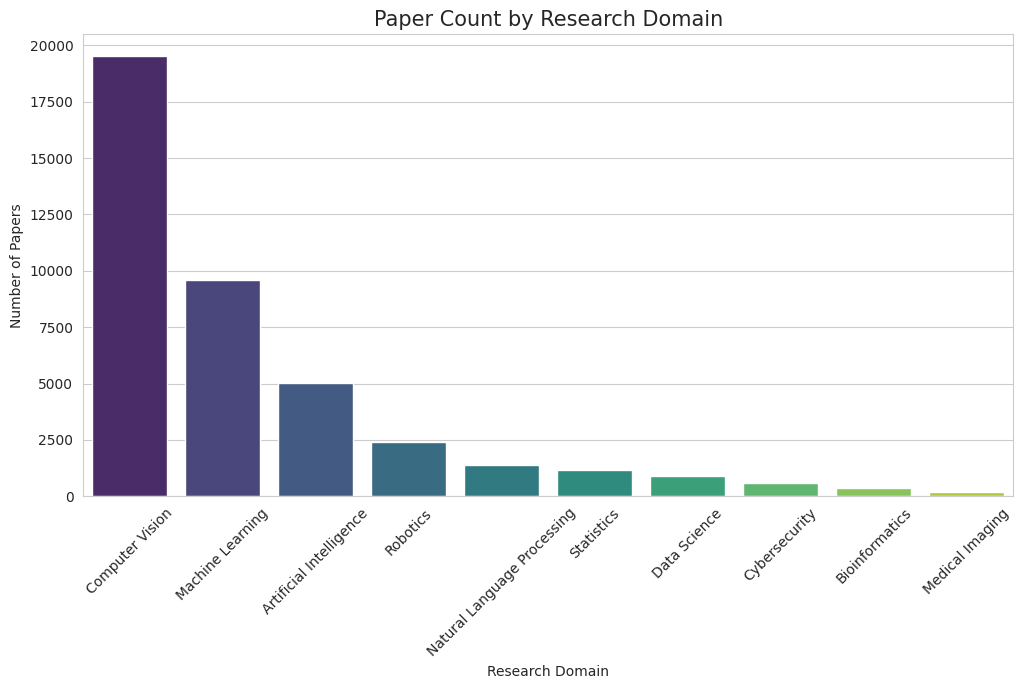

In [ ]:
plt.figure(figsize=(12,6))

domain_counts = df["primary_domain"].value_counts()

sns.barplot(
    x=domain_counts.index,
    y=domain_counts.values,
    palette="viridis"
)

plt.title("Paper Count by Research Domain", fontsize=15)
plt.xlabel("Research Domain")
plt.ylabel("Number of Papers")
plt.xticks(rotation=45)

plt.show()

In [ ]:
from collections import Counter

category_counter = Counter()

for labels in df["terms_list"]:
    category_counter.update(labels)

category_df = pd.DataFrame(
    category_counter.items(),
    columns=["Category","Count"]
).sort_values(
    by="Count",
    ascending=False
)

display(category_df.head(20))

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=category_df.head(20),
    x="Count",
    y="Category",
    palette="rocket"
)

plt.title("Top 20 Research Categories")

plt.show()

In [ ]:
primary_counts = df["primary_domain"].value_counts()

print(primary_counts)

primary_domain
Computer Vision                19518
Machine Learning                9601
Artificial Intelligence         5022
Robotics                        2396
Natural Language Processing     1384
Statistics                      1173
Data Science                     892
Cybersecurity                    603
Bioinformatics                   349
Medical Imaging                  189
Name: count, dtype: int64


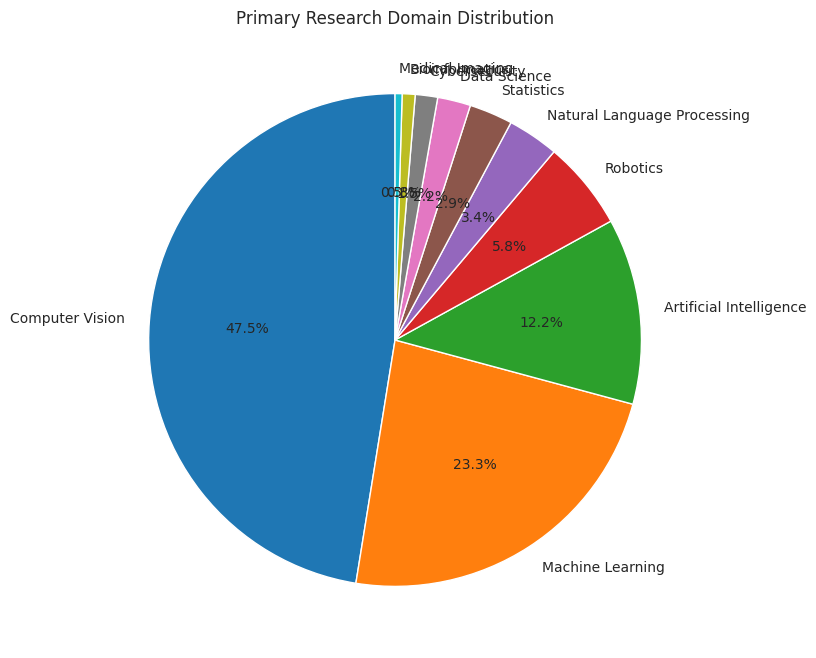

In [ ]:
plt.figure(figsize=(8,8))

primary_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")
plt.title("Primary Research Domain Distribution")

plt.show()

In [ ]:
combo_counts = (
    df["terms_list"]
    .apply(lambda x: ", ".join(sorted(x)))
    .value_counts()
)

combo_df = combo_counts.reset_index()
combo_df.columns = ["Category Combination","Count"]

display(combo_df.head(20))

,Category Combination,Count
0,cs.CV,13160
1,"cs.LG, stat.ML",5459
2,cs.LG,2134
3,"cs.CV, cs.LG",1844
4,"cs.AI, cs.LG, stat.ML",1341
5,"cs.AI, cs.LG",1251
6,"cs.CV, cs.LG, stat.ML",954
7,"cs.AI, cs.CV",689
8,"cs.CV, cs.LG, eess.IV",629
9,"cs.CV, eess.IV",552


In [ ]:
pair_counter = Counter()

for labels in df["terms_list"]:

    labels = sorted(set(labels))

    if len(labels) >= 2:

        pair_counter.update(combinations(labels,2))

In [ ]:
pair_counter = Counter()

for labels in df["terms_list"]:

    labels = sorted(set(labels))

    if len(labels) >= 2:

        pair_counter.update(combinations(labels,2))

In [ ]:
pair_df = pd.DataFrame(
    pair_counter.items(),
    columns=["Pair","Count"]
)

pair_df["Pair"] = pair_df["Pair"].apply(lambda x: " + ".join(x))

pair_df = pair_df.sort_values(
    by="Count",
    ascending=False
)

display(pair_df.head(20))

,Pair,Count
3,cs.LG + stat.ML,12485
25,cs.CV + cs.LG,6099
0,cs.AI + cs.LG,5137
48,cs.AI + stat.ML,2268
77,cs.AI + cs.CV,2083
78,cs.CV + stat.ML,1771
105,cs.CV + eess.IV,1717
161,cs.LG + eess.IV,1058
149,cs.CV + cs.RO,972
128,cs.LG + cs.NE,960


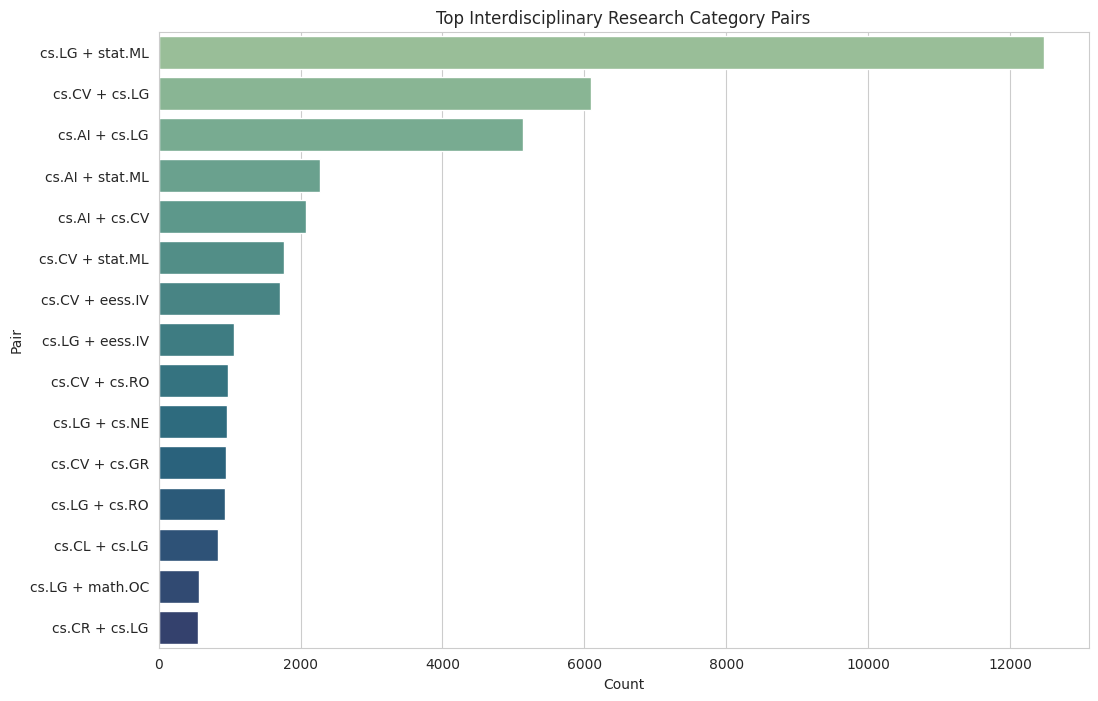

In [ ]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=pair_df.head(15),
    x="Count",
    y="Pair",
    palette="crest"
)

plt.title("Top Interdisciplinary Research Category Pairs")

plt.show()

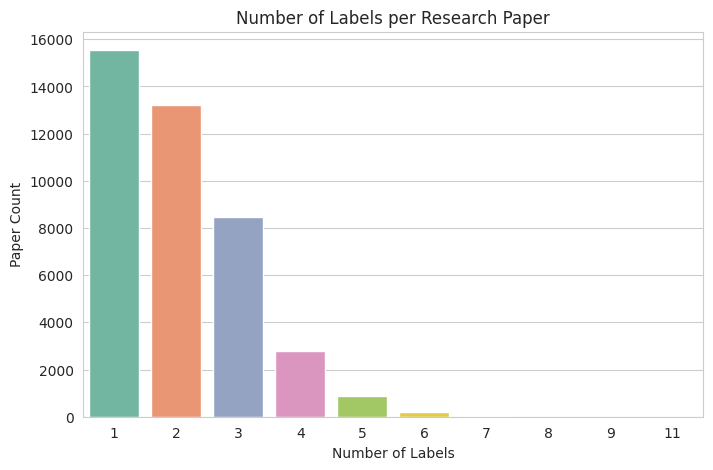

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="num_labels",
    palette="Set2"
)

plt.title("Number of Labels per Research Paper")
plt.xlabel("Number of Labels")
plt.ylabel("Paper Count")

plt.show()

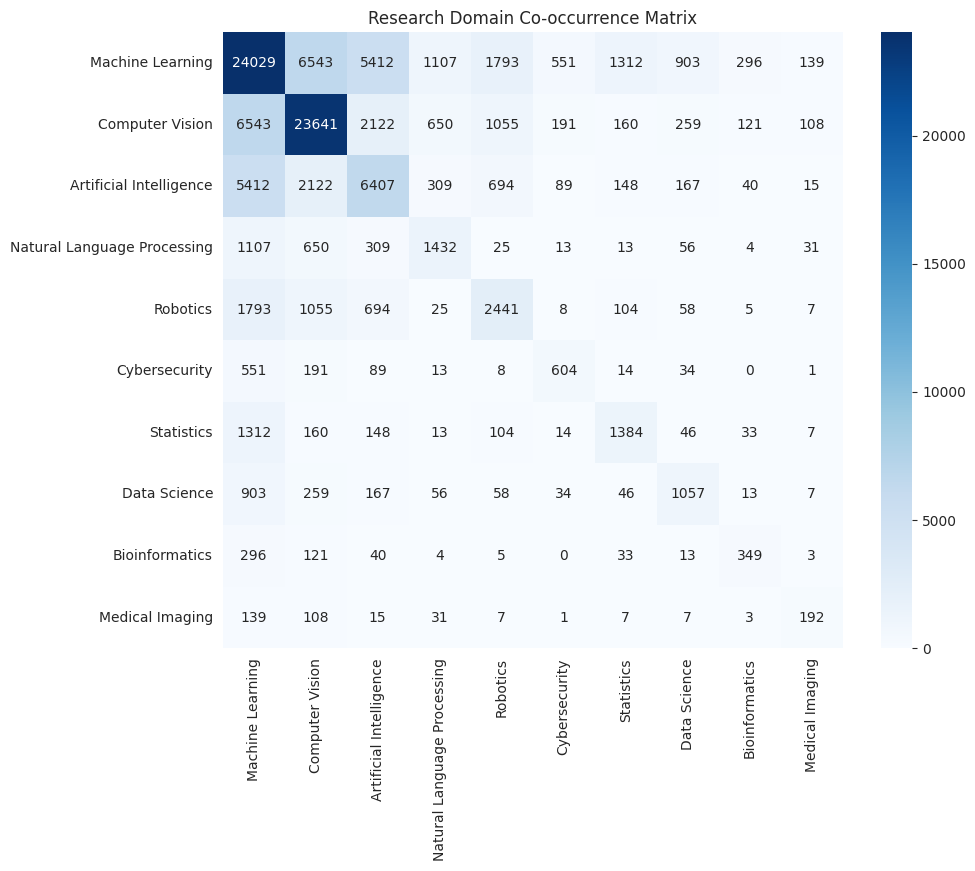

In [ ]:
topic_columns = [
    "Machine Learning",
    "Computer Vision",
    "Artificial Intelligence",
    "Natural Language Processing",
    "Robotics",
    "Cybersecurity",
    "Statistics",
    "Data Science",
    "Bioinformatics",
    "Medical Imaging"
]

co_matrix = df[topic_columns].T.dot(df[topic_columns])

plt.figure(figsize=(10,8))

sns.heatmap(
    co_matrix,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Research Domain Co-occurrence Matrix")

plt.show()

4.2 Abstract-Based EDA

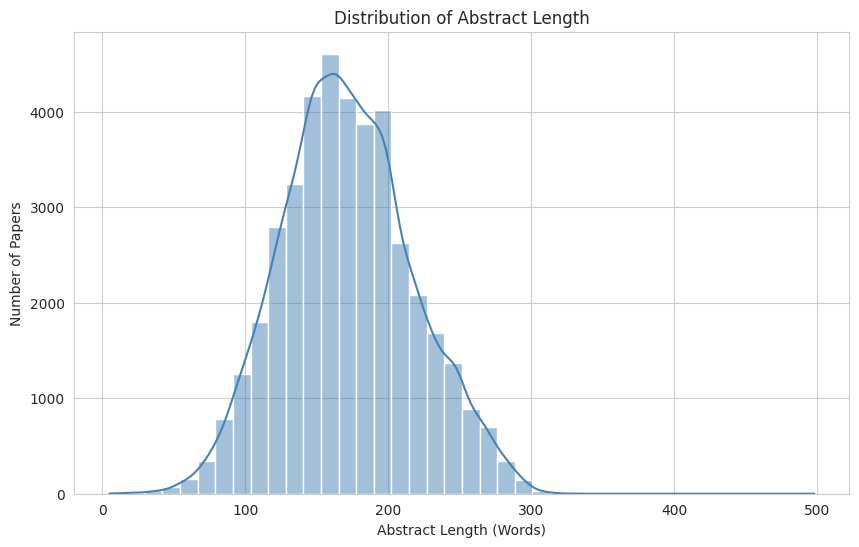

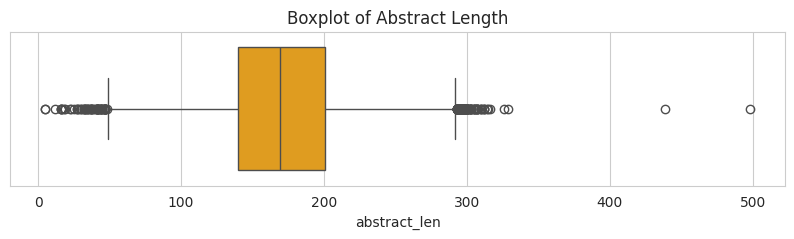

In [ ]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

#1. Plot Abstract Length Distribution
#Histogram
plt.figure(figsize=(10,6))

sns.histplot(
    df["abstract_len"],
    bins=40,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Abstract Length")
plt.xlabel("Abstract Length (Words)")
plt.ylabel("Number of Papers")

plt.show()
#Box Plot
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["abstract_len"],
    color="orange"
)

plt.title("Boxplot of Abstract Length")

plt.show()


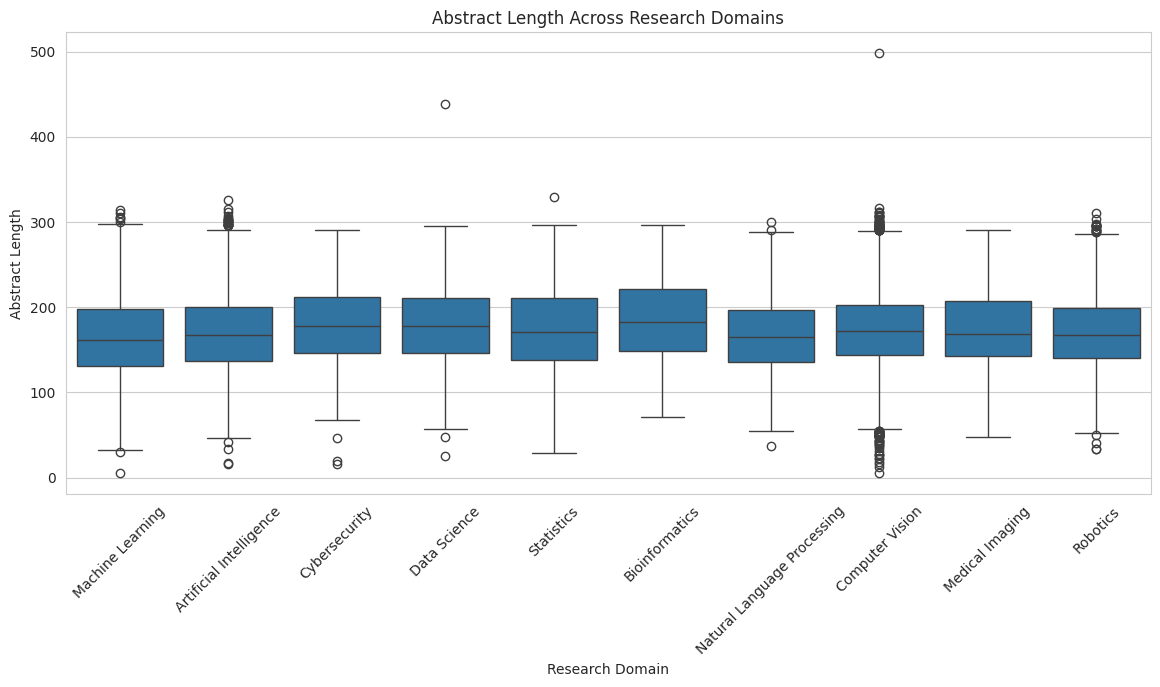

primary_domain
Bioinformatics                 184.120344
Cybersecurity                  179.376451
Data Science                   178.504484
Statistics                     175.791134
Medical Imaging                174.973545
Computer Vision                173.886208
Robotics                       170.633973
Artificial Intelligence        170.031063
Natural Language Processing    167.868497
Machine Learning               165.775857
Name: abstract_len, dtype: float64


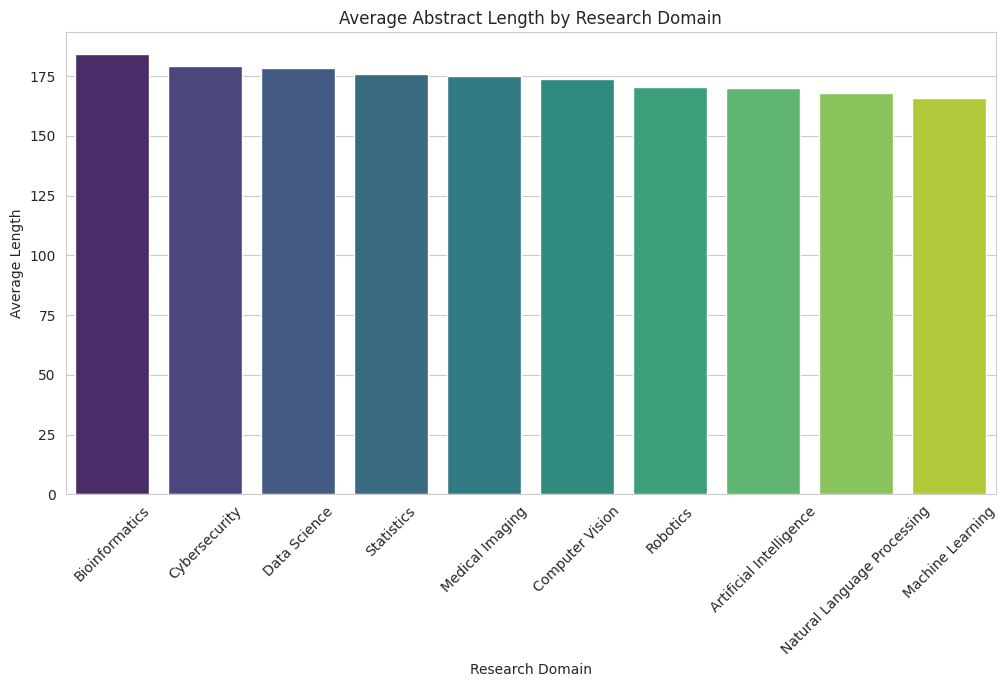

In [ ]:
#2. Compare Abstract Length Across Research Domains(Box Plot)

plt.figure(figsize=(14,6))

sns.boxplot(
    data=df,
    x="primary_domain",
    y="abstract_len"
)

plt.xticks(rotation=45)

plt.title("Abstract Length Across Research Domains")
plt.xlabel("Research Domain")
plt.ylabel("Abstract Length")

plt.show()

#Average Abstract Length by Domain

avg_length = (
    df.groupby("primary_domain")["abstract_len"]
      .mean()
      .sort_values(ascending=False)
)

print(avg_length)

#Visualization

plt.figure(figsize=(12,6))

sns.barplot(
    x=avg_length.index,
    y=avg_length.values,
    palette="viridis"
)

plt.xticks(rotation=45)

plt.title("Average Abstract Length by Research Domain")
plt.xlabel("Research Domain")
plt.ylabel("Average Length")

plt.show()

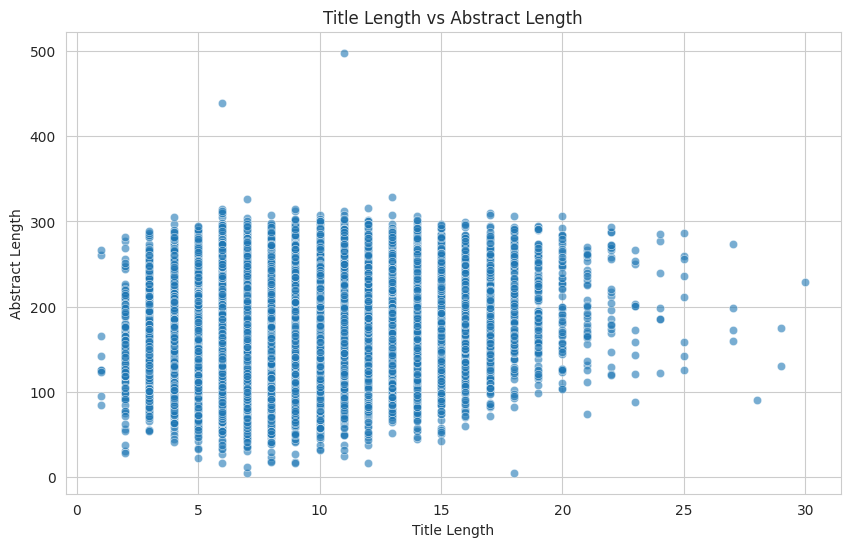

Correlation between title length and abstract length: 0.157


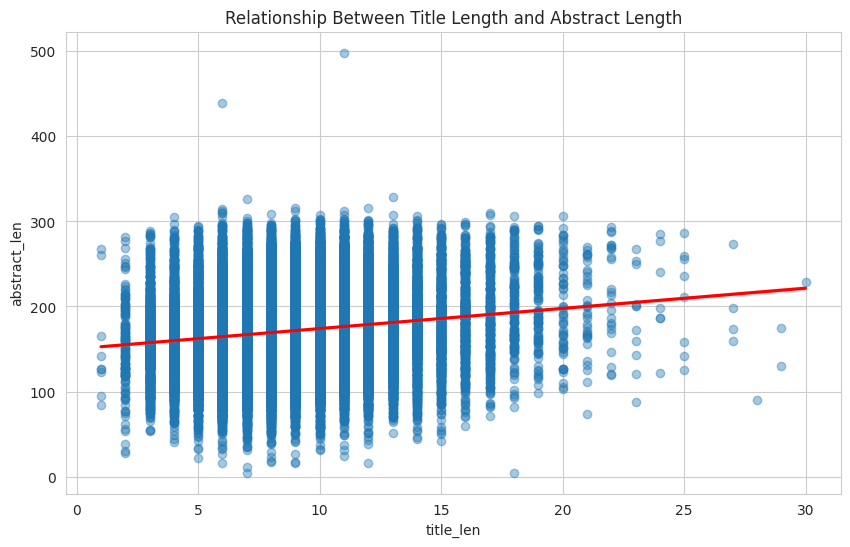

In [ ]:

#3. Analyze Title Length vs Abstract Length(Scatter Plot)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="title_len",
    y="abstract_len",
    alpha=0.6
)

plt.title("Title Length vs Abstract Length")
plt.xlabel("Title Length")
plt.ylabel("Abstract Length")

plt.show()

#Correlation

correlation = df["title_len"].corr(df["abstract_len"])

print(f"Correlation between title length and abstract length: {correlation:.3f}")

#Regression Plot

plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="title_len",
    y="abstract_len",
    scatter_kws={"alpha":0.4},
    line_kws={"color":"red"}
)

plt.title("Relationship Between Title Length and Abstract Length")

plt.show()


In [ ]:
#4. Identify Papers with Very Short or Very Long Abstracts
#Descriptive Statistics

print(df["abstract_len"].describe())

#Short Abstracts Example: fewer than 50 words.

short_abstracts = df[df["abstract_len"] < 50]

print("Number of Short Abstracts:", len(short_abstracts))

short_abstracts[
    ["titles","primary_domain","abstract_len"]
].head(20)

#Long Abstracts Example: more than 500 words.

long_abstracts = df[df["abstract_len"] > 500]

print("Number of Long Abstracts:", len(long_abstracts))

long_abstracts[
    ["titles","primary_domain","abstract_len"]
].head(20)

#Top 10 Longest Abstracts
longest = df.sort_values(
    by="abstract_len",
    ascending=False
)

longest[
    ["titles","primary_domain","abstract_len"]
].head(10)

#Top 10 Shortest Abstracts
shortest = df.sort_values(
    by="abstract_len",
    ascending=True
)

shortest[
    ["titles","primary_domain","abstract_len"]
].head(10)


count    41127.000000
mean       171.456975
std         45.950679
min          5.000000
25%        140.000000
50%        169.000000
75%        201.000000
max        498.000000
Name: abstract_len, dtype: float64
Number of Short Abstracts: 68
Number of Long Abstracts: 0


,titles,primary_domain,abstract_len
8719,Diverse Behavior Is What Game AI Needs: Genera...,Machine Learning,5
17773,Fast Efficient Object Detection Using Selectiv...,Computer Vision,5
37831,A Machine-Learning Framework for Design for Ma...,Computer Vision,12
38238,Approximated Structured Prediction for Learnin...,Artificial Intelligence,16
20457,Brain MRI Image Super Resolution using Phase S...,Computer Vision,16
1537,Adaptive Gradient for Adversarial Perturbation...,Cybersecurity,16
27545,BMVC 2019: Workshop on Interpretable and Expla...,Artificial Intelligence,17
36396,Exploration of object recognition from 3D poin...,Computer Vision,18
31390,Generating Adversarial Perturbation with Root ...,Cybersecurity,19
37465,Structure and Motion from Multiframes,Computer Vision,22


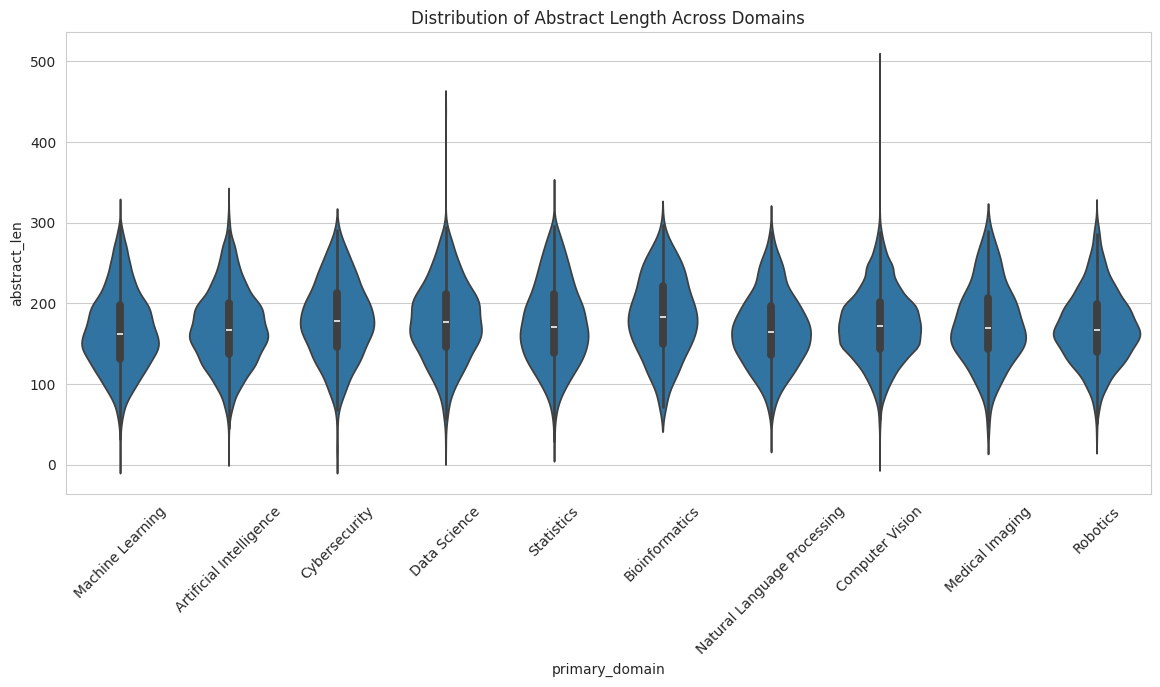

In [ ]:
#5. Distribution of Abstract Length by Domain (Violin Plot)
plt.figure(figsize=(14,6))

sns.violinplot(
    data=df,
    x="primary_domain",
    y="abstract_len"
)

plt.xticks(rotation=45)

plt.title("Distribution of Abstract Length Across Domains")

plt.show()

                             title_len  abstract_len
primary_domain                                      
Artificial Intelligence           8.69        170.03
Bioinformatics                   10.12        184.12
Computer Vision                   9.01        173.89
Cybersecurity                     9.01        179.38
Data Science                      9.08        178.50
Machine Learning                  8.60        165.78
Medical Imaging                   9.62        174.97
Natural Language Processing       8.56        167.87
Robotics                          9.24        170.63
Statistics                        9.49        175.79


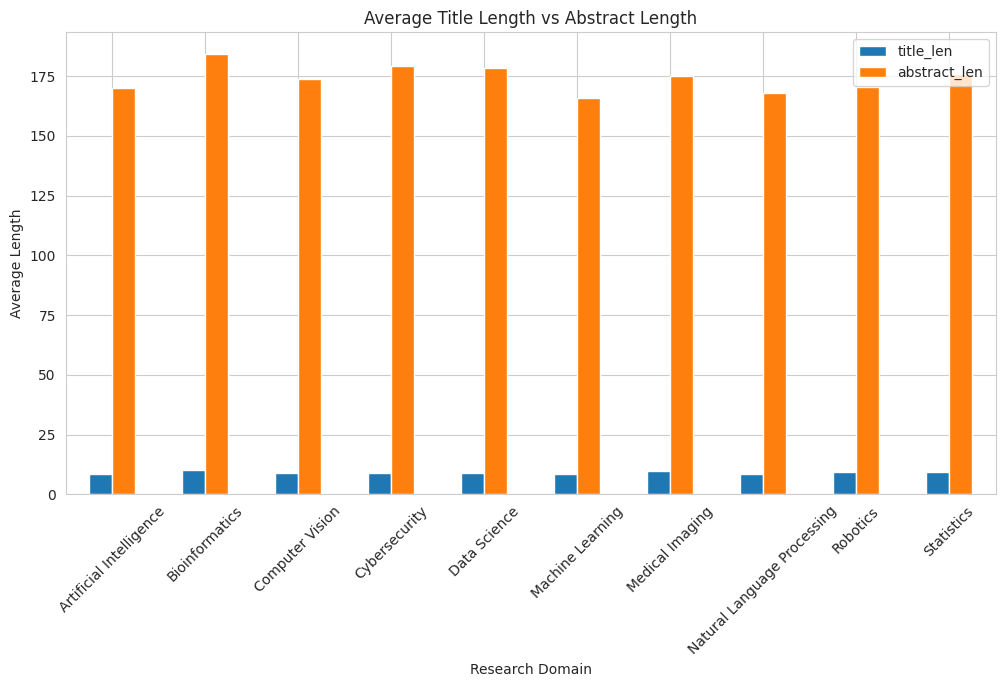

In [ ]:
#6. Average Title Length vs Average Abstract Length by Domain
comparison = (
    df.groupby("primary_domain")[["title_len","abstract_len"]]
      .mean()
      .round(2)
)

print(comparison)

#Visualization

comparison.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Average Title Length vs Abstract Length")
plt.xlabel("Research Domain")
plt.ylabel("Average Length")

plt.xticks(rotation=45)

plt.show()

4.3 Text-Centric EDA

In [ ]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

sns.set_style("whitegrid")

#1. Generate Word Clouds for Each Research Domain
domains = sorted(df["primary_domain"].unique())

for domain in domains:

    text = " ".join(
        df[df["primary_domain"] == domain]["processed_text"]
        .dropna()
        .astype(str)
    )

    wc = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        max_words=200
    ).generate(text)

    plt.figure(figsize=(14,6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud - {domain}", fontsize=16)

    plt.show()

Artificial Intelligence


,Word,Score
1593,learning,0.054753
1772,model,0.043884
1730,method,0.030134
700,data,0.029797
2036,policy,0.029210
1837,network,0.029146
2279,reinforcement,0.028183
1371,image,0.027968
127,agent,0.027844
2725,task,0.027251


Bioinformatics


,Word,Score
1748,model,0.044068
1604,learning,0.041571
737,data,0.039933
1827,network,0.035061
1716,method,0.029759
418,brain,0.027180
1829,neural,0.026362
1379,image,0.025127
1248,graph,0.024961
2759,time,0.024802


Computer Vision


...

,Word,Score
1361,image,0.047267
1770,model,0.046769
1589,learning,0.034271
1565,language,0.033393
2720,task,0.032731
254,attention,0.029995
2938,visual,0.027968
2741,text,0.026823
706,data,0.026680
1735,method,0.026637


Robotics


,Word,Score
1557,learning,0.053518
1752,model,0.036680
2040,policy,0.034773
1706,method,0.032593
1855,object,0.031280
139,algorithm,0.030451
2737,task,0.029479
2290,reinforcement,0.028671
677,data,0.027645
294,based,0.027477


Statistics


,Word,Score
1754,model,0.047892
695,data,0.041296
1561,learning,0.040368
2765,time,0.032916
1709,method,0.031959
1242,graph,0.031575
1829,network,0.029903
155,algorithm,0.028789
2474,series,0.025738
306,based,0.024236


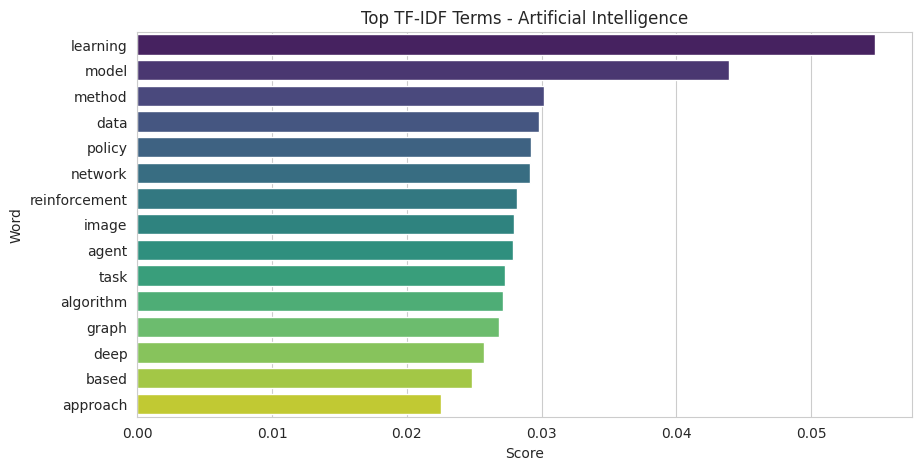

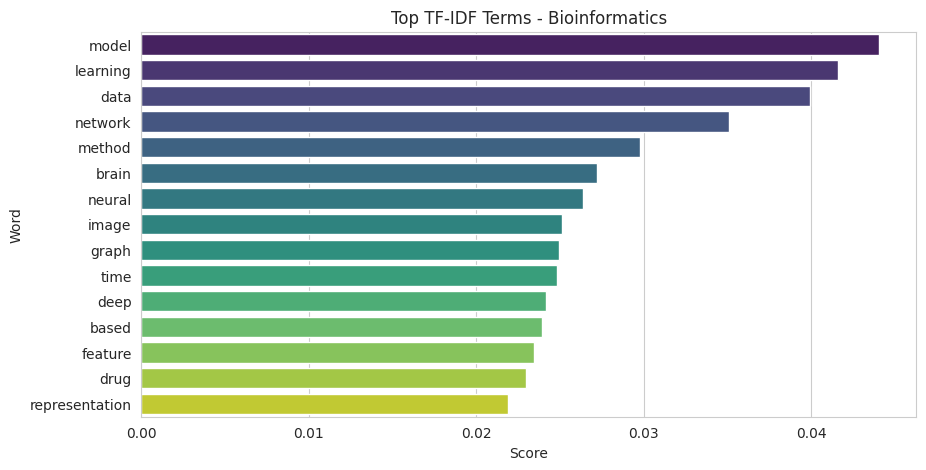

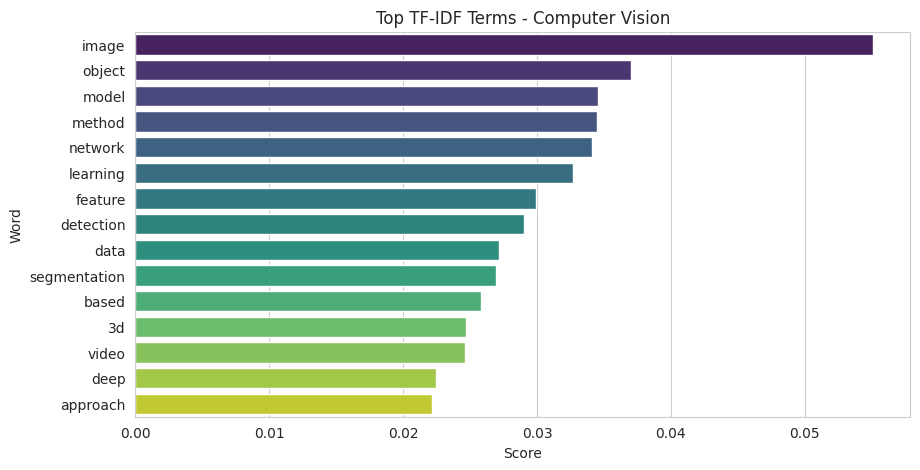

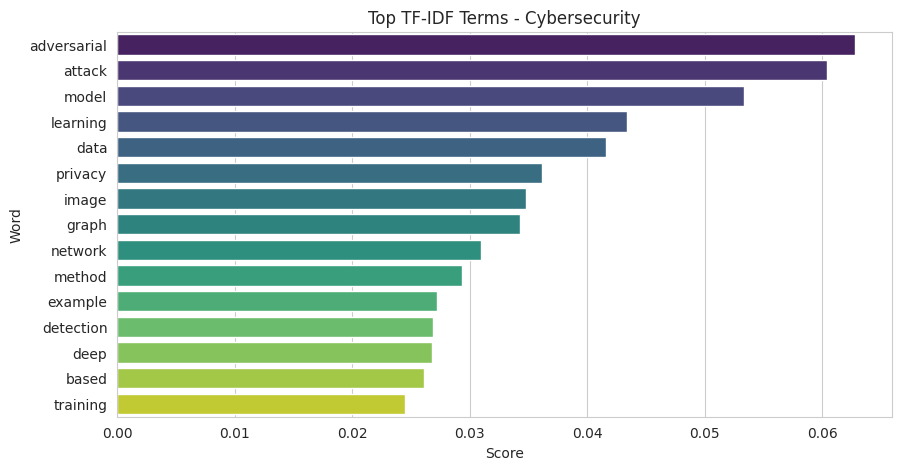

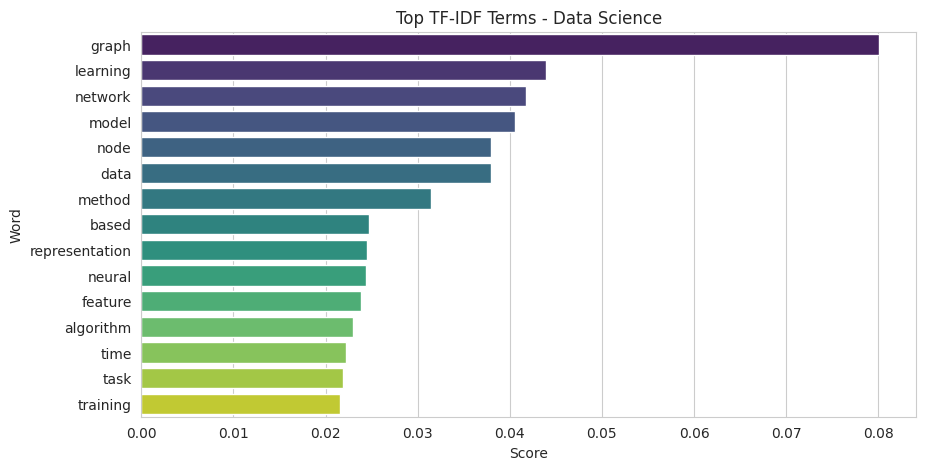

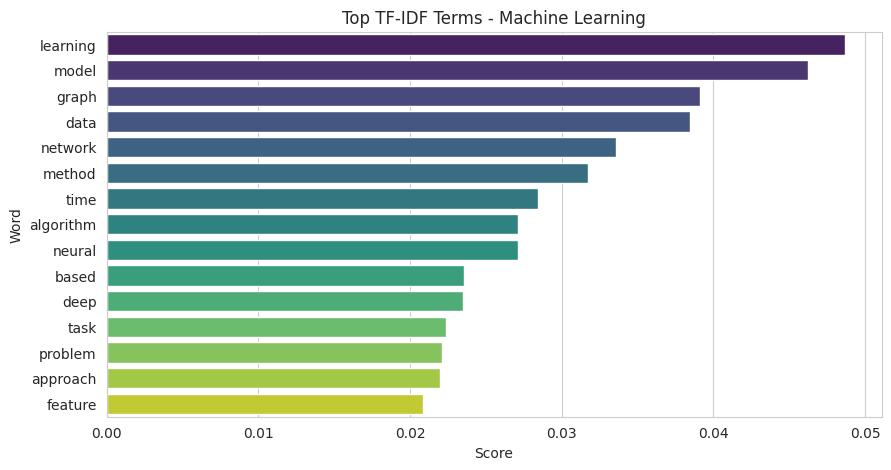

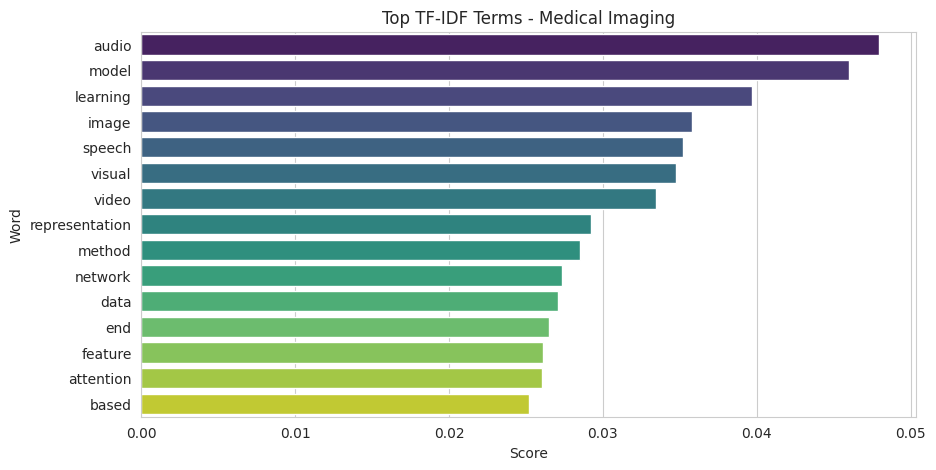

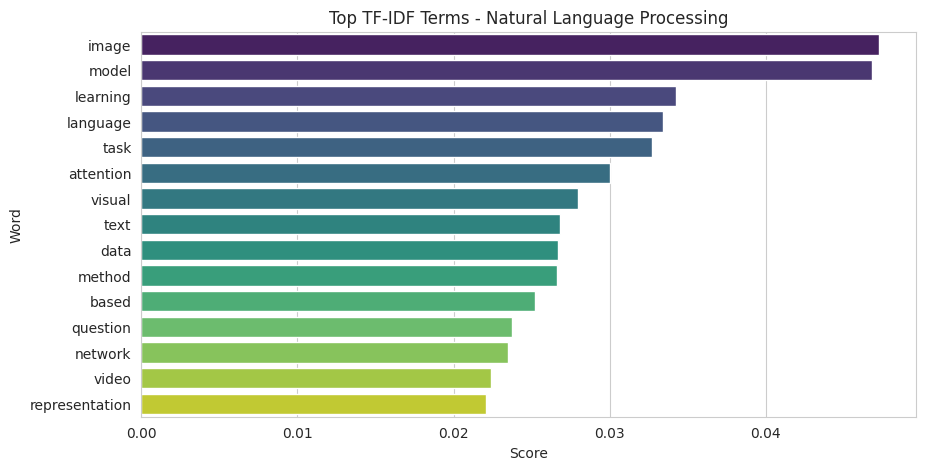

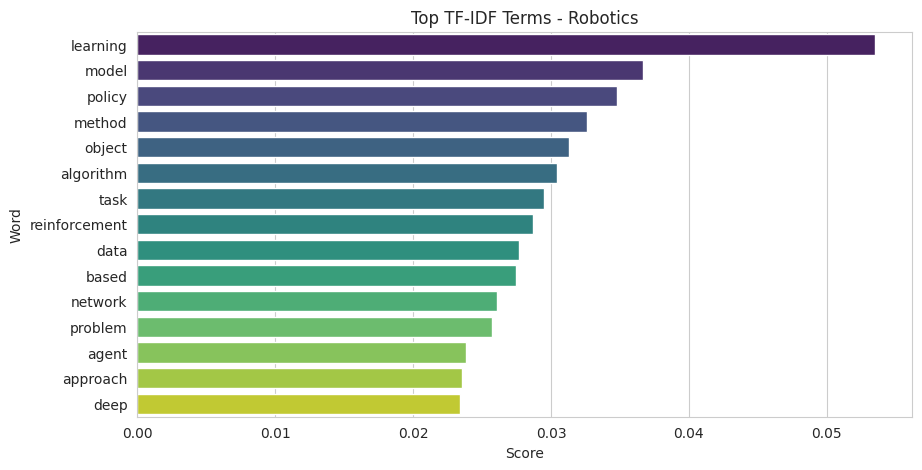

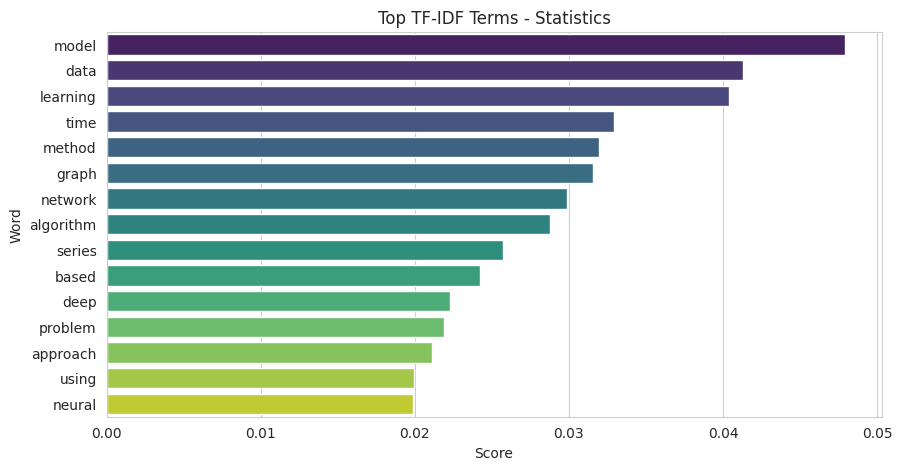

In [ ]:
#2. Extract Top TF-IDF Terms Per Domain
domains = sorted(df["primary_domain"].unique())

for domain in domains:

    texts = df[df["primary_domain"] == domain]["processed_text"]

    vectorizer = TfidfVectorizer(
        max_features=3000,
        stop_words="english"
    )

    X = vectorizer.fit_transform(texts)

    scores = X.mean(axis=0).A1

    words = vectorizer.get_feature_names_out()

    tfidf_df = pd.DataFrame({
        "Word": words,
        "Score": scores
    })

    tfidf_df = tfidf_df.sort_values(
        by="Score",
        ascending=False
    )

    print("="*70)
    print(domain)
    display(tfidf_df.head(20))
#Visualization of Top TF-IDF Terms

for domain in domains:

    texts = df[df["primary_domain"] == domain]["processed_text"]

    vectorizer = TfidfVectorizer(
        max_features=3000,
        stop_words="english"
    )

    X = vectorizer.fit_transform(texts)

    scores = X.mean(axis=0).A1

    words = vectorizer.get_feature_names_out()

    tfidf_df = pd.DataFrame({
        "Word": words,
        "Score": scores
    }).sort_values(
        by="Score",
        ascending=False
    ).head(15)

    plt.figure(figsize=(10,5))

    sns.barplot(
        data=tfidf_df,
        x="Score",
        y="Word",
        palette="viridis"
    )

    plt.title(f"Top TF-IDF Terms - {domain}")

    plt.show()

In [ ]:

#3. Identify Frequent Technical Terms

#Using your processed text.

all_words = " ".join(df["processed_text"]).split()

word_freq = Counter(all_words)

technical_terms = pd.DataFrame(
    word_freq.items(),
    columns=["Term","Frequency"]
)

technical_terms = technical_terms.sort_values(
    by="Frequency",
    ascending=False
)

technical_terms.head(30)

#Visualization

plt.figure(figsize=(10,8))

sns.barplot(
    data=technical_terms.head(20),
    x="Frequency",
    y="Term",
    palette="rocket"
)

plt.title("Top 20 Frequent Technical Terms")

plt.show()

In [ ]:

#4. Compare Keywords Across Research Domains

#Since you already extracted TF-IDF keywords, compare them.

domain_keywords = {}

for domain in domains:

    words = []

    for keyword_list in df[df["primary_domain"]==domain]["tfidf_keywords"]:

        if isinstance(keyword_list,list):

            words.extend(keyword_list)

        elif isinstance(keyword_list,str):

            words.extend(keyword_list.split(","))

    domain_keywords[domain] = Counter(words).most_common(15)

#Display results.

for domain, keywords in domain_keywords.items():

    print("="*70)
    print(domain)

    display(
        pd.DataFrame(
            keywords,
            columns=["Keyword","Frequency"]
        )
    )
#Compare Top Keywords Using Bar Charts
for domain, keywords in domain_keywords.items():

    keyword_df = pd.DataFrame(
        keywords,
        columns=["Keyword","Frequency"]
    )

    plt.figure(figsize=(10,5))

    sns.barplot(
        data=keyword_df,
        x="Frequency",
        y="Keyword",
        palette="mako"
    )

    plt.title(f"Top Keywords - {domain}")

    plt.show()

In [ ]:

#5. Compare KeyBERT Keywords (Bonus)
keybert_domain = {}

for domain in domains:

    words = []

    for kw in df[df["primary_domain"]==domain]["keybert_keywords"]:

        if isinstance(kw,list):

            words.extend(kw)

    keybert_domain[domain] = Counter(words).most_common(15)

#Display

for domain in keybert_domain:

    print(domain)

    display(pd.DataFrame(
        keybert_domain[domain],
        columns=["Keyword","Frequency"]
    ))

In [ ]:

#6. Compare Noun Phrases Across Domains (Bonus)
noun_domain = {}

for domain in domains:

    phrases = []

    for np in df[df["primary_domain"]==domain]["noun_phrases"]:

        if isinstance(np,list):

            phrases.extend(np)

    noun_domain[domain] = Counter(phrases).most_common(15)

#Display

for domain in noun_domain:

    print(domain)

    display(pd.DataFrame(
        noun_domain[domain],
        columns=["Noun Phrase","Frequency"]
    ))


In [ ]:
#7. Domain-wise Vocabulary Size (Bonus)
vocab = {}

for domain in domains:

    text = " ".join(
        df[df["primary_domain"]==domain]["processed_text"]
    )

    vocab[domain] = len(set(text.split()))

vocab_df = pd.DataFrame(
    vocab.items(),
    columns=["Domain","Vocabulary Size"]
)

vocab_df = vocab_df.sort_values(
    by="Vocabulary Size",
    ascending=False
)

display(vocab_df)

#Visualization

plt.figure(figsize=(12,5))

sns.barplot(
    data=vocab_df,
    x="Vocabulary Size",
    y="Domain",
    palette="coolwarm"
)

plt.title("Vocabulary Size by Research Domain")

plt.show()

4.4 Keyword and Keyphrase EDA

In [ ]:
#Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

sns.set_style("whitegrid")

#1. Identify Most Frequent Keywords (TF-IDF + KeyBERT)
#TF-IDF Keywords

tfidf_counter = Counter()

for keywords in df["tfidf_keywords"]:

    if isinstance(keywords, list):
        tfidf_counter.update([k.strip() for k in keywords])

    elif isinstance(keywords, str):
        tfidf_counter.update(
            [k.strip() for k in keywords.split(",")]
        )

tfidf_freq = pd.DataFrame(
    tfidf_counter.items(),
    columns=["Keyword","Frequency"]
)

tfidf_freq = tfidf_freq.sort_values(
    by="Frequency",
    ascending=False
)

display(tfidf_freq.head(30))

#KeyBERT Keywords

keybert_counter = Counter()

for keywords in df["keybert_keywords"]:

    if isinstance(keywords, list):
        keybert_counter.update(keywords)

keybert_freq = pd.DataFrame(
    keybert_counter.items(),
    columns=["Keyword","Frequency"]
)

keybert_freq = keybert_freq.sort_values(
    by="Frequency",
    ascending=False
)

display(keybert_freq.head(30))

In [ ]:
#2. Extract Top Keyphrases for Each Research Category

#Using noun_phrases

domains = sorted(df["primary_domain"].unique())

for domain in domains:

    phrase_counter = Counter()

    subset = df[df["primary_domain"]==domain]

    for phrases in subset["noun_phrases"]:

        if isinstance(phrases,list):

            phrase_counter.update(phrases)

    phrase_df = pd.DataFrame(
        phrase_counter.items(),
        columns=["Keyphrase","Frequency"]
    )

    phrase_df = phrase_df.sort_values(
        by="Frequency",
        ascending=False
    )

    print("="*70)
    print(domain)

    display(phrase_df.head(20))

In [ ]:
#3. Compare Technical Vocabulary Between Domains

#Using noun_phrases

comparison = {}

for domain in domains:

    counter = Counter()

    subset = df[df["primary_domain"]==domain]

    for phrases in subset["noun_phrases"]:

        if isinstance(phrases,list):
            counter.update(phrases)

    comparison[domain] = counter.most_common(15)

#Display

for domain in comparison:

    print("\n")
    print("="*70)
    print(domain)

    display(pd.DataFrame(
        comparison[domain],
        columns=["Technical Vocabulary","Frequency"]
    ))

In [ ]:
#4. Visualize Keyword Frequency Using Bar Charts
#TF-IDF Keywords
plt.figure(figsize=(12,7))

sns.barplot(
    data=tfidf_freq.head(20),
    x="Frequency",
    y="Keyword",
    palette="viridis"
)

plt.title("Top 20 TF-IDF Keywords")

plt.xlabel("Frequency")
plt.ylabel("Keyword")

plt.show()

#KeyBERT Keywords

plt.figure(figsize=(12,7))

sns.barplot(
    data=keybert_freq.head(20),
    x="Frequency",
    y="Keyword",
    palette="rocket"
)

plt.title("Top 20 KeyBERT Keywords")

plt.xlabel("Frequency")
plt.ylabel("Keyword")

plt.show()

In [ ]:
#5. Visualize Top Keyphrases for Every Domain
for domain in domains:

    phrase_counter = Counter()

    subset = df[df["primary_domain"]==domain]

    for phrases in subset["noun_phrases"]:

        if isinstance(phrases,list):

            phrase_counter.update(phrases)

    phrase_df = pd.DataFrame(
        phrase_counter.items(),
        columns=["Keyphrase","Frequency"]
    )

    phrase_df = phrase_df.sort_values(
        by="Frequency",
        ascending=False
    ).head(15)

    plt.figure(figsize=(10,5))

    sns.barplot(
        data=phrase_df,
        x="Frequency",
        y="Keyphrase",
        palette="mako"
    )

    plt.title(f"Top Keyphrases - {domain}")

    plt.show()


In [ ]:
#6. Compare Top Keywords Across Domains
for domain in domains:

    counter = Counter()

    subset = df[df["primary_domain"]==domain]

    for keywords in subset["tfidf_keywords"]:

        if isinstance(keywords,list):
            counter.update(keywords)

        elif isinstance(keywords,str):
            counter.update(
                [k.strip() for k in keywords.split(",")]
            )

    keyword_df = pd.DataFrame(
        counter.items(),
        columns=["Keyword","Frequency"]
    )

    keyword_df = keyword_df.sort_values(
        by="Frequency",
        ascending=False
    ).head(15)

    plt.figure(figsize=(10,5))

    sns.barplot(
        data=keyword_df,
        x="Frequency",
        y="Keyword",
        palette="crest"
    )

    plt.title(f"Top Keywords - {domain}")

    plt.show()

In [ ]:
#7. Top Technical Vocabulary Across the Entire Dataset (Bonus)
technical_counter = Counter()

for phrases in df["noun_phrases"]:

    if isinstance(phrases,list):

        technical_counter.update(phrases)

technical_df = pd.DataFrame(
    technical_counter.items(),
    columns=["Technical Vocabulary","Frequency"]
)

technical_df = technical_df.sort_values(
    by="Frequency",
    ascending=False
)

display(technical_df.head(30))

#Visualization

plt.figure(figsize=(12,8))

sns.barplot(
    data=technical_df.head(20),
    x="Frequency",
    y="Technical Vocabulary",
    palette="coolwarm"
)

plt.title("Top Technical Vocabulary")

plt.show()

In [ ]:
#8. Word Cloud of Keywords (Bonus)
from wordcloud import WordCloud

text = " ".join(tfidf_freq["Keyword"].astype(str))

wc = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,7))

plt.imshow(wc)

plt.axis("off")

plt.title("Word Cloud of Keywords")

plt.show()

5.1 Research Domain Classification


In [ ]:
  import pandas as pd
  import numpy as np

  from sklearn.model_selection import train_test_split
  from sklearn.preprocessing import LabelEncoder
  from sklearn.pipeline import Pipeline
  from sklearn.compose import ColumnTransformer

  from sklearn.feature_extraction.text import CountVectorizer
  from sklearn.feature_extraction.text import TfidfVectorizer

  from sklearn.linear_model import LogisticRegression
  from sklearn.naive_bayes import MultinomialNB
  from sklearn.ensemble import RandomForestClassifier

  from sklearn.metrics import (
      accuracy_score,
      classification_report,
      confusion_matrix,
      ConfusionMatrixDisplay
  )

  import matplotlib.pyplot as plt
  import seaborn as sns


In [ ]:
#Step 2: Prepare Dataset
# Keep only required columns

data = df[[
    "processed_text",
    "primary_domain",
    "title_len",
    "abstract_len",
    "tfidf_keywords"
]].copy()

In [ ]:
#Step 3: Keyword Count Feature
def keyword_count(x):

    if isinstance(x,list):
        return len(x)

    elif isinstance(x,str):
        return len(x.split(","))

    return 0


data["keyword_count"] = data["tfidf_keywords"].apply(keyword_count)


In [ ]:
  import pandas as pd
  import numpy as np

  from sklearn.model_selection import train_test_split
  from sklearn.preprocessing import LabelEncoder
  from sklearn.pipeline import Pipeline
  from sklearn.compose import ColumnTransformer

  from sklearn.feature_extraction.text import CountVectorizer
  from sklearn.feature_extraction.text import TfidfVectorizer

  from sklearn.linear_model import LogisticRegression
  from sklearn.naive_bayes import MultinomialNB
  from sklearn.ensemble import RandomForestClassifier

  from sklearn.metrics import (
      accuracy_score,
      classification_report,
      confusion_matrix,
      ConfusionMatrixDisplay
  )

  import matplotlib.pyplot as plt
  import seaborn as sns


In [ ]:

#Step 4: Encode Target Labels
label_encoder = LabelEncoder()

data["label"] = label_encoder.fit_transform(
    data["primary_domain"]
)

print(label_encoder.classes_)


In [ ]:

#Step 5: Train Test Split
X = data[[
    "processed_text",
    "title_len",
    "abstract_len",
    "keyword_count"
]]

y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
#Step 6: Create BoW Features
bow_preprocessor = ColumnTransformer(

    transformers=[

        (
            "text",

            CountVectorizer(
                max_features=10000,
                ngram_range=(1,2),
                stop_words="english"
            ),

            "processed_text"
        ),

        (
            "numeric",

            "passthrough",

            [
                "title_len",
                "abstract_len",
                "keyword_count"
            ]
        )

    ]
)

In [ ]:
#Step 7: Create TF-IDF Features
tfidf_preprocessor = ColumnTransformer(

    transformers=[

        (
            "text",

            TfidfVectorizer(
                max_features=10000,
                ngram_range=(1,2),
                stop_words="english"
            ),

            "processed_text"
        ),

        (
            "numeric",

            "passthrough",

            [
                "title_len",
                "abstract_len",
                "keyword_count"
            ]
        )

    ]
)

In [ ]:

#Step 8: Define Models
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=2000),

    "Naive Bayes":
        MultinomialNB(),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        )
}

Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                             precision    recall  f1-score   support

    Artificial Intelligence       0.29      0.26      0.27      1004
             Bioinformatics       0.30      0.17      0.22        70
            Computer Vision       0.81      0.85      0.83      3904
              Cybersecurity       0.53      0.43      0.47       121
               Data Science       0.25      0.16      0.20       178
           Machine Learning       0.55      0.60      0.57      1920
            Medical Imaging       0.19      0.08      0.11        38
Natural Language Processing       0.47      0.39      0.42       277
                   Robotics       0.40      0.37      0.38       479
                 Statistics       0.24      0.21      0.23       235

                   accuracy                           0.62      8226
                  macro avg       0.40      0.35      0.37      8226
               weighted avg       0.61      0.62      0.62      8226



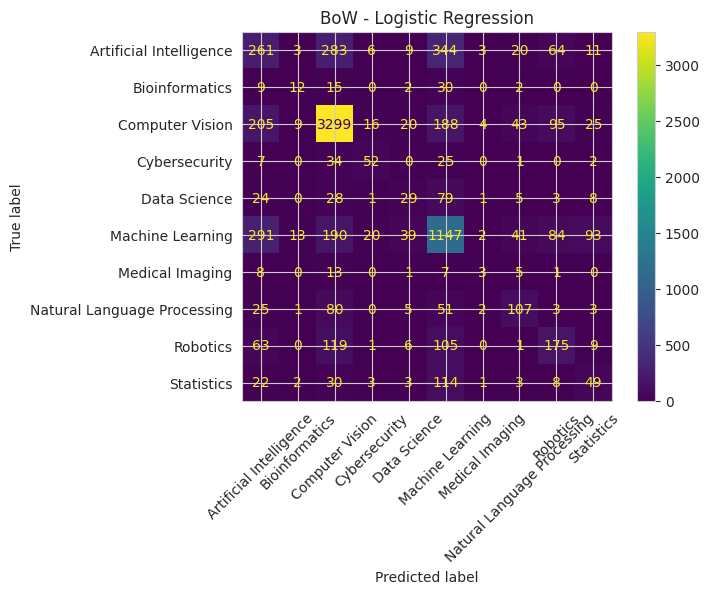

Naive Bayes
                             precision    recall  f1-score   support

    Artificial Intelligence       0.39      0.26      0.32      1004
             Bioinformatics       0.12      0.31      0.18        70
            Computer Vision       0.87      0.76      0.81      3904
              Cybersecurity       0.35      0.76      0.48       121
               Data Science       0.19      0.45      0.27       178
           Machine Learning       0.61      0.46      0.52      1920
            Medical Imaging       0.12      0.13      0.13        38
Natural Language Processing       0.37      0.70      0.48       277
                   Robotics       0.38      0.57      0.46       479
                 Statistics       0.19      0.47      0.27       235

                   accuracy                           0.59      8226
                  macro avg       0.36      0.49      0.39      8226
               weighted avg       0.66      0.59      0.61      8226



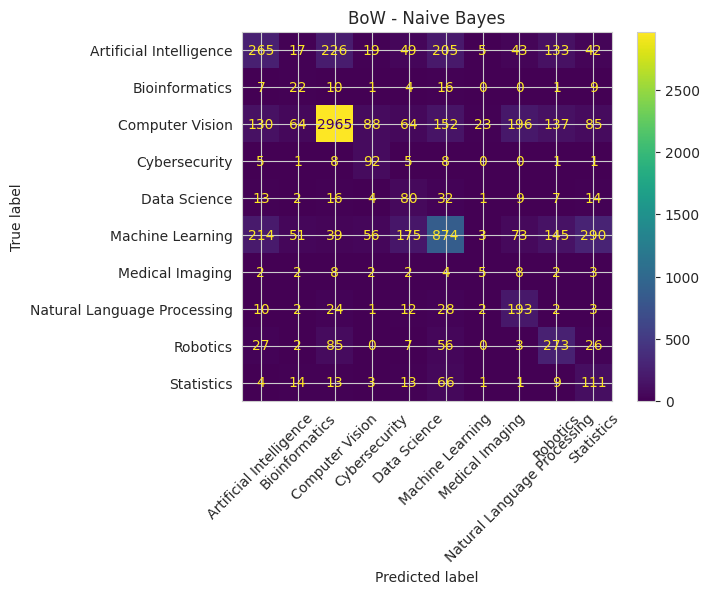

Random Forest


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                             precision    recall  f1-score   support

    Artificial Intelligence       0.47      0.18      0.26      1004
             Bioinformatics       0.00      0.00      0.00        70
            Computer Vision       0.74      0.96      0.84      3904
              Cybersecurity       0.50      0.01      0.02       121
               Data Science       0.00      0.00      0.00       178
           Machine Learning       0.54      0.77      0.64      1920
            Medical Imaging       0.00      0.00      0.00        38
Natural Language Processing       0.42      0.02      0.03       277
                   Robotics       0.84      0.09      0.16       479
                 Statistics       0.00      0.00      0.00       235

                   accuracy                           0.66      8226
                  macro avg       0.35      0.20      0.19      8226
               weighted avg       0.61      0.66      0.59      8226



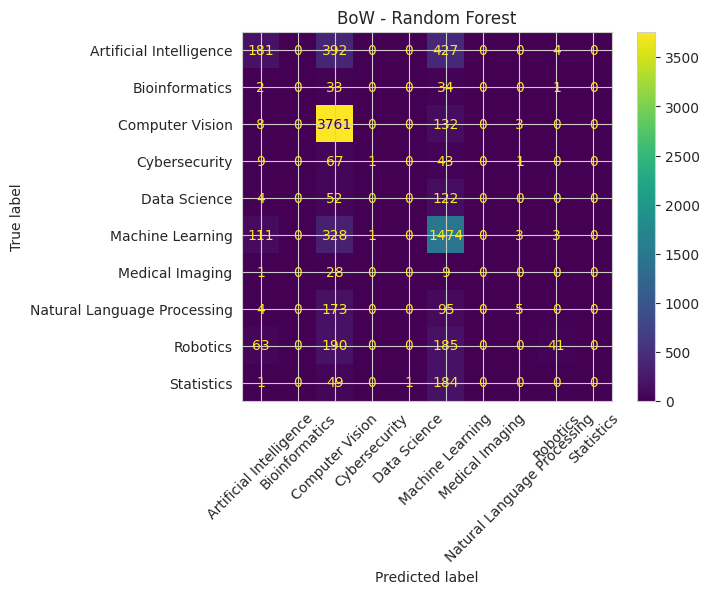

In [ ]:
#Step 9: Train Using Bag of Words
bow_results = []

for model_name, model in models.items():

    print("="*70)

    print(model_name)

    pipeline = Pipeline([

        ("features", bow_preprocessor),

        ("model", model)

    ])

    pipeline.fit(X_train,y_train)

    predictions = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test,predictions)

    bow_results.append([

        model_name,
        accuracy

    ])

    print(classification_report(

        y_test,
        predictions,
        target_names=label_encoder.classes_

    ))

    cm = confusion_matrix(y_test,predictions)

    ConfusionMatrixDisplay(
        cm,
        display_labels=label_encoder.classes_
    ).plot(
        xticks_rotation=45
    )

    plt.title(f"BoW - {model_name}")

    plt.show()

Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre

                             precision    recall  f1-score   support

    Artificial Intelligence       0.41      0.29      0.34      1004
             Bioinformatics       0.00      0.00      0.00        70
            Computer Vision       0.80      0.92      0.86      3904
              Cybersecurity       0.63      0.22      0.33       121
               Data Science       0.06      0.01      0.01       178
           Machine Learning       0.55      0.79      0.65      1920
            Medical Imaging       0.00      0.00      0.00        38
Natural Language Processing       0.57      0.19      0.29       277
                   Robotics       0.65      0.19      0.29       479
                 Statistics       0.00      0.00      0.00       235

                   accuracy                           0.68      8226
                  macro avg       0.37      0.26      0.28      8226
               weighted avg       0.63      0.68      0.63      8226



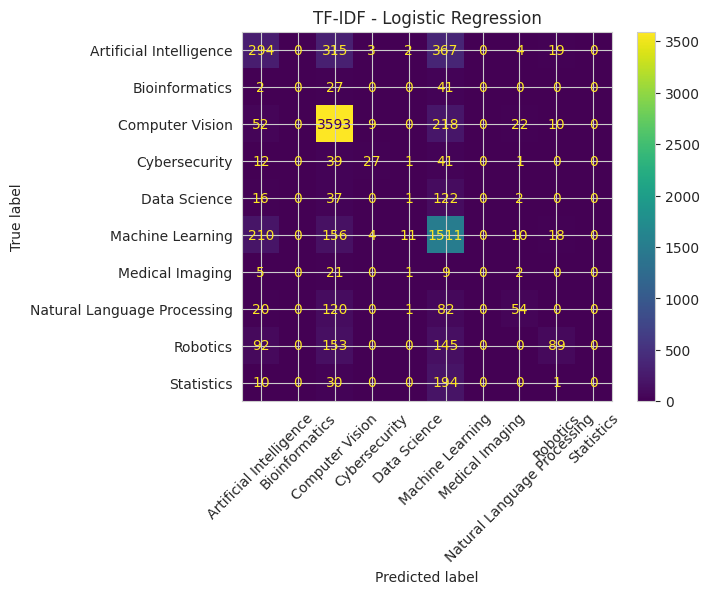

Naive Bayes


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                             precision    recall  f1-score   support

    Artificial Intelligence       0.43      0.19      0.26      1004
             Bioinformatics       0.00      0.00      0.00        70
            Computer Vision       0.77      0.94      0.85      3904
              Cybersecurity       0.00      0.00      0.00       121
               Data Science       0.00      0.00      0.00       178
           Machine Learning       0.53      0.83      0.65      1920
            Medical Imaging       0.00      0.00      0.00        38
Natural Language Processing       0.50      0.01      0.01       277
                   Robotics       0.71      0.04      0.07       479
                 Statistics       0.00      0.00      0.00       235

                   accuracy                           0.67      8226
                  macro avg       0.29      0.20      0.18      8226
               weighted avg       0.60      0.67      0.59      8226



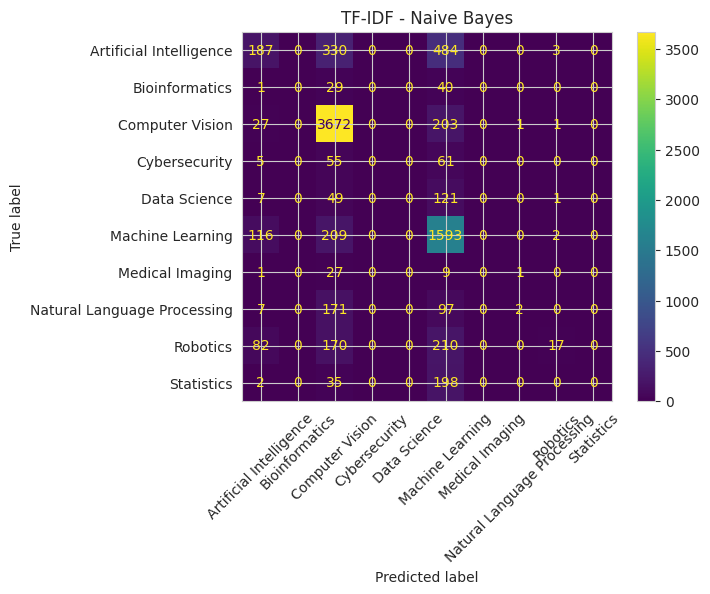

Random Forest


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                             precision    recall  f1-score   support

    Artificial Intelligence       0.48      0.19      0.27      1004
             Bioinformatics       0.00      0.00      0.00        70
            Computer Vision       0.74      0.96      0.84      3904
              Cybersecurity       0.33      0.01      0.02       121
               Data Science       0.00      0.00      0.00       178
           Machine Learning       0.54      0.76      0.63      1920
            Medical Imaging       0.00      0.00      0.00        38
Natural Language Processing       0.33      0.00      0.01       277
                   Robotics       0.82      0.09      0.16       479
                 Statistics       0.00      0.00      0.00       235

                   accuracy                           0.66      8226
                  macro avg       0.33      0.20      0.19      8226
               weighted avg       0.60      0.66      0.59      8226



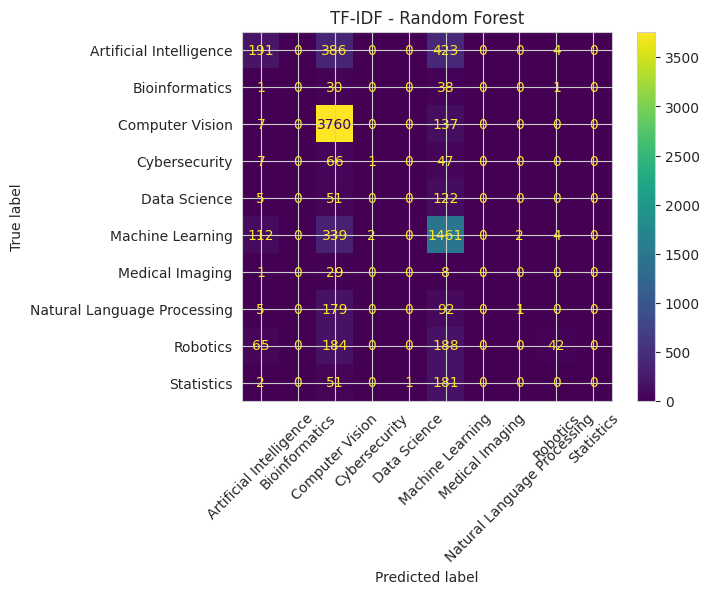

In [ ]:
#Step 10: Train Using TF-IDF
tfidf_results = []

for model_name, model in models.items():

    print("="*70)

    print(model_name)

    pipeline = Pipeline([

        ("features", tfidf_preprocessor),

        ("model", model)

    ])

    pipeline.fit(X_train,y_train)

    predictions = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test,predictions)

    tfidf_results.append([

        model_name,
        accuracy

    ])

    print(classification_report(

        y_test,
        predictions,
        target_names=label_encoder.classes_

    ))

    cm = confusion_matrix(y_test,predictions)

    ConfusionMatrixDisplay(
        cm,
        display_labels=label_encoder.classes_
    ).plot(
        xticks_rotation=45
    )

    plt.title(f"TF-IDF - {model_name}")

    plt.show()

In [ ]:
#Step 11: Compare Results
bow_df = pd.DataFrame(

    bow_results,

    columns=[

        "Model",
        "BoW Accuracy"

    ]

)

tfidf_df = pd.DataFrame(

    tfidf_results,

    columns=[

        "Model",
        "TFIDF Accuracy"

    ]

)

comparison = bow_df.merge(

    tfidf_df,

    on="Model"

)

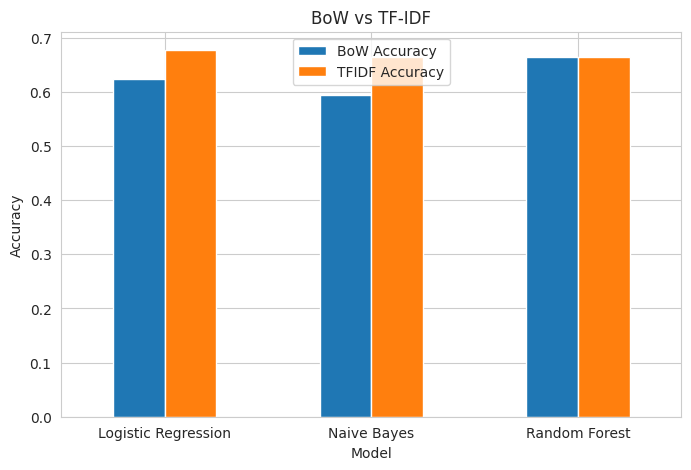

In [ ]:
#comparison
#Step 12: Accuracy Comparison Plot
comparison.set_index("Model").plot(

    kind="bar",

    figsize=(8,5)

)

plt.ylabel("Accuracy")

plt.title("BoW vs TF-IDF")

plt.xticks(rotation=0)

plt.show()

In [ ]:
#Models saved #1
import joblib
import os

# Create folder to save models
os.makedirs("saved_models", exist_ok=True)

Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.6241
                             precision    recall  f1-score   support

    Artificial Intelligence       0.29      0.26      0.27      1004
             Bioinformatics       0.30      0.17      0.22        70
            Computer Vision       0.81      0.85      0.83      3904
              Cybersecurity       0.53      0.43      0.47       121
               Data Science       0.25      0.16      0.20       178
           Machine Learning       0.55      0.60      0.57      1920
            Medical Imaging       0.19      0.08      0.11        38
Natural Language Processing       0.47      0.39      0.42       277
                   Robotics       0.40      0.37      0.38       479
                 Statistics       0.24      0.21      0.23       235

                   accuracy                           0.62      8226
                  macro avg       0.40      0.35      0.37      8226
               weighted avg       0.61      0.62      0.62      8226



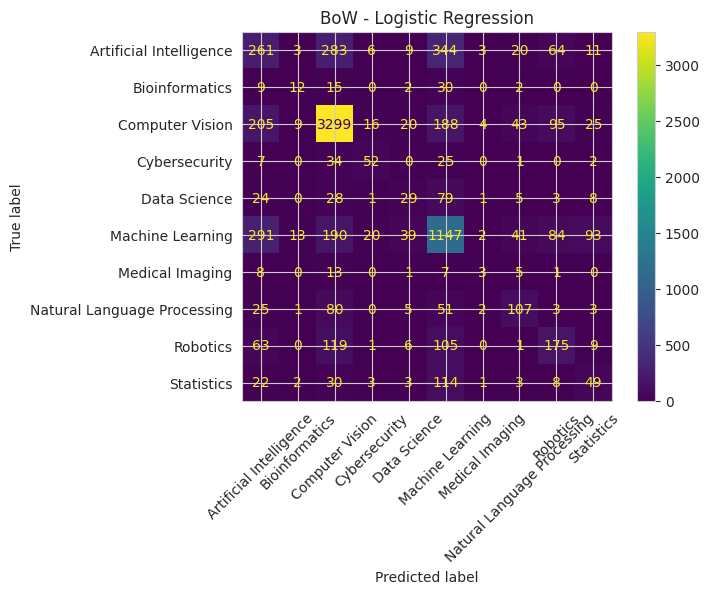

Naive Bayes
Accuracy: 0.5932
                             precision    recall  f1-score   support

    Artificial Intelligence       0.39      0.26      0.32      1004
             Bioinformatics       0.12      0.31      0.18        70
            Computer Vision       0.87      0.76      0.81      3904
              Cybersecurity       0.35      0.76      0.48       121
               Data Science       0.19      0.45      0.27       178
           Machine Learning       0.61      0.46      0.52      1920
            Medical Imaging       0.12      0.13      0.13        38
Natural Language Processing       0.37      0.70      0.48       277
                   Robotics       0.38      0.57      0.46       479
                 Statistics       0.19      0.47      0.27       235

                   accuracy                           0.59      8226
                  macro avg       0.36      0.49      0.39      8226
               weighted avg       0.66      0.59      0.61      8226



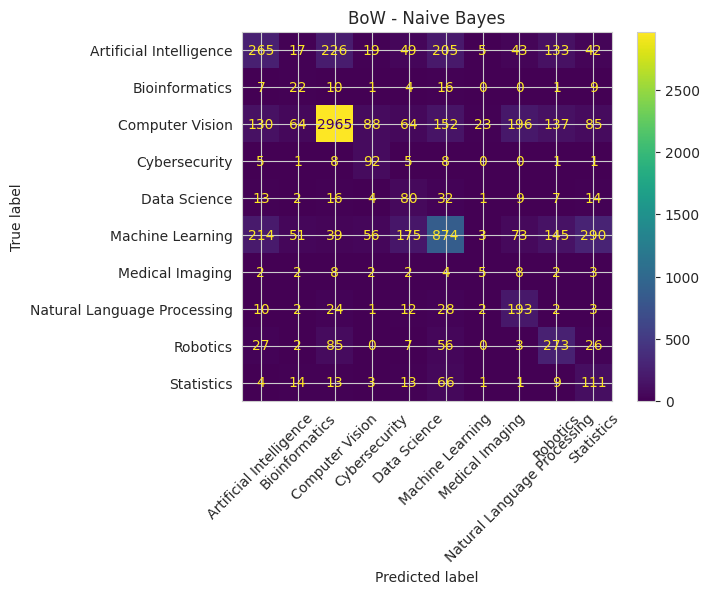

Random Forest


In [ ]:
#2
import joblib
import os

os.makedirs("saved_models", exist_ok=True)

bow_results = []

best_accuracy = 0
best_model_name = None
best_pipeline = None

for model_name, model in models.items():

    print("=" * 70)
    print(model_name)

    pipeline = Pipeline([
        ("features", bow_preprocessor),
        ("model", model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    predictions = pipeline.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, predictions)

    bow_results.append([model_name, accuracy])

    print(f"Accuracy: {accuracy:.4f}")

    print(classification_report(
        y_test,
        predictions,
        target_names=label_encoder.classes_
    ))

    # Save the best model
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model_name = model_name
        best_pipeline = pipeline

    # Confusion Matrix
    cm = confusion_matrix(y_test, predictions)

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    ).plot(xticks_rotation=45)

    plt.title(f"BoW - {model_name}")
    plt.show()

# Save Best Model
joblib.dump(best_pipeline, "saved_models/best_bow_model.pkl")

print("="*70)
print(f"Best Model : {best_model_name}")
print(f"Best Accuracy : {best_accuracy:.4f}")
print("Best model saved successfully!")

In [ ]:
#3
joblib.dump(
    pipeline,
    f"saved_models/{model_name.replace(' ', '_')}_bow.pkl"
)

[2] Custom Deep Learning Models

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/arxiv_clean (1).csv")
#df = pd.read_csv("/content/arxiv_clean (1).csv")
#df.head()
#df = pd.read_csv("/content/drive/MyDrive/arxiv_clean.csv")
df.head()

,terms,titles,abstracts,terms_list,num_labels,abstract_len,title_len,clean_abstract,clean_title,combined_text,...,Machine Learning,Computer Vision,Artificial Intelligence,Natural Language Processing,Robotics,Cybersecurity,Statistics,Data Science,Bioinformatics,Medical Imaging
0,['cs.LG'],Multi-Level Attention Pooling for Graph Neural...,Graph neural networks (GNNs) have been widely ...,['cs.LG'],1,247,13,Graph neural networks GNNs have been widely us...,Multi-Level Attention Pooling for Graph Neural...,Multi-Level Attention Pooling for Graph Neural...,...,1,0,0,0,0,0,0,0,0,0
1,"['cs.LG', 'cs.AI']",Decision Forests vs. Deep Networks: Conceptual...,Deep networks and decision forests (such as ra...,"['cs.LG', 'cs.AI']",2,234,14,Deep networks and decision forests such as ran...,Decision Forests vs. Deep Networks Conceptual ...,Decision Forests vs. Deep Networks Conceptual ...,...,1,0,1,0,0,0,0,0,0,0
2,"['cs.LG', 'cs.CR', 'stat.ML']",Power up! Robust Graph Convolutional Network v...,Graph convolutional networks (GCNs) are powerf...,"['cs.LG', 'cs.CR', 'stat.ML']",3,117,9,Graph convolutional networks GCNs are powerful...,Power up Robust Graph Convolutional Network vi...,Power up Robust Graph Convolutional Network vi...,...,1,0,0,0,0,1,0,0,0,0
3,"['cs.LG', 'cs.CR']",Releasing Graph Neural Networks with Different...,With the increasing popularity of Graph Neural...,"['cs.LG', 'cs.CR']",2,216,8,With the increasing popularity of Graph Neural...,Releasing Graph Neural Networks with Different...,Releasing Graph Neural Networks with Different...,...,1,0,0,0,0,1,0,0,0,0
4,['cs.LG'],Recurrence-Aware Long-Term Cognitive Network f...,Machine learning solutions for pattern classif...,['cs.LG'],1,197,8,Machine learning solutions for pattern classif...,Recurrence-Aware Long-Term Cognitive Network f...,Recurrence-Aware Long-Term Cognitive Network f...,...,1,0,0,0,0,0,0,0,0,0


In [ ]:
df.columns

Index(['terms', 'titles', 'abstracts', 'terms_list', 'num_labels',
       'abstract_len', 'title_len', 'clean_abstract', 'clean_title',
       'combined_text', 'word_tokens', 'sentence_tokens',
       'tokens_no_stopwords', 'lemmatized_tokens', 'processed_text',
       'primary_domain', 'multi_label_topics', 'Machine Learning',
       'Computer Vision', 'Artificial Intelligence',
       'Natural Language Processing', 'Robotics', 'Cybersecurity',
       'Statistics', 'Data Science', 'Bioinformatics', 'Medical Imaging'],
      dtype='object')

In [ ]:
target = "primary_domain"
#Input Feature

#Use the cleaned combined text:

X = df["processed_text"]   # or df["combined_text"]
y = df["primary_domain"]

In [ ]:
!pip install -q gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 19.8 MB/s eta 0:00:00


In [ ]:
from gensim.models import Word2Vec

In [ ]:
#Step 1 Import Libraries

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    LSTM,
    Bidirectional,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

from tensorflow.keras.optimizers import Adam

#from tensorflow.keras.wrappers.scikit_learn import KerasClassifier

from sklearn.model_selection import RandomizedSearchCV

from gensim.models import Word2Vec


In [ ]:

#Step 2 Prepare Data

X = df["processed_text"].astype(str)

y = df["primary_domain"]

#Encode labels

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

num_classes = len(label_encoder.classes_)

print(label_encoder.classes_)

['Artificial Intelligence' 'Bioinformatics' 'Computer Vision'
 'Cybersecurity' 'Data Science' 'Machine Learning' 'Medical Imaging'
 'Natural Language Processing' 'Robotics' 'Statistics']


In [ ]:
#Step 3 Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
#Step 4 Tokenization
MAX_WORDS = 50000
MAX_LEN = 300

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding='post'
)

In [ ]:
!pip install gensim

In [ ]:
pip install gensim

In [ ]:
from gensim.models import Word2Vec

In [ ]:
from gensim.models import Word2Vec
print(Word2Vec)

<class 'gensim.models.word2vec.Word2Vec'>


In [ ]:
#Step 5 Train Word2Vec Embedding

sentences = [text.split() for text in X_train]

word2vec = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

#Vocabulary

word_index = tokenizer.word_index

embedding_dim = 100

embedding_matrix = np.zeros((MAX_WORDS, embedding_dim))

#Fill embedding matrix

for word, i in word_index.items():

    if i >= MAX_WORDS:
        continue

    if word in word2vec.wv:

        embedding_matrix[i] = word2vec.wv[word]


In [ ]:
#Step 6 Class Weight

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

print(class_weights)

{0: np.float64(0.818840219014435), 1: np.float64(11.79247311827957), 2: np.float64(0.21071474317919817), 3: np.float64(6.825933609958506), 4: np.float64(4.6079831932773105), 5: np.float64(0.42834266371566204), 6: np.float64(21.788741721854304), 7: np.float64(2.9720867208672086), 8: np.float64(1.7162754303599375), 9: np.float64(3.5075692963752667)}


In [ ]:
#Model 1 CNN Text Classifier
cnn_model = Sequential()

cnn_model.add(
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=100,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False
    )
)

cnn_model.add(
    Conv1D(
        filters=256,
        kernel_size=5,
        activation='relu'
    )
)

cnn_model.add(GlobalMaxPooling1D())

cnn_model.add(
    Dense(
        128,
        activation='relu',
        kernel_regularizer=l2(0.001)
    )
)

cnn_model.add(Dropout(0.5))

cnn_model.add(Dense(num_classes, activation='softmax'))

cnn_model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

cnn_model.summary()

#Train CNN

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True
)

history = cnn_model.fit(

    X_train_pad,

    y_train,

    validation_split=0.2,

    epochs=20,

    batch_size=64,

    class_weight=class_weights,

    callbacks=[early_stop]
)

#Evaluate

loss, accuracy = cnn_model.evaluate(X_test_pad, y_test)

print("CNN Accuracy :", accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     5,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,000,000 (19.07 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 5,000,000 (19.07 MB)

Epoch 1/20
412/412 ━━━━━━━━━━━━━━━━━━━━ 111s 264ms/step - accuracy: 0.0989 - loss: 2.4654 - val_accuracy: 0.1387 - val_loss: 2.2757
Epoch 2/20
412/412 ━━━━━━━━━━━━━━━━━━━━ 118s 207ms/step - accuracy: 0.0977 - loss: 2.2428 - val_accuracy: 0.3907 - val_loss: 2.1082
Epoch 3/20
412/412 ━━━━━━━━━━━━━━━━━━━━ 69s 168ms/step - accuracy: 0.2369 - loss: 2.0933 - val_accuracy: 0.3723 - val_loss: 1.9115
Epoch 4/20
412/412 ━━━━━━━━━━━━━━━━━━━━ 85s 175ms/step - accuracy: 0.2116 - loss: 2.0035 - val_accuracy: 0.3729 - val_loss: 1.8785
Epoch 5/20
412/412 ━━━━━━━━━━━━━━━━━━━━ 74s 155ms/step - accuracy: 0.2294 - loss: 1.9182 - val_accuracy: 0.3114 - val_loss: 1.9951
Epoch 6/20
412/412 ━━━━━━━━━━━━━━━━━━━━ 89s 172ms/step - accuracy: 0.2181 - loss: 1.8761 - val_accuracy: 0.3692 - val_loss: 1.8324
Epoch 7/20
412/412 ━━━━━━━━━━━━━━━━━━━━ 64s 156ms/step - accuracy: 0.2152 - loss: 1.8216 - val_accuracy: 0.3310 - val_loss: 1.8310
Epoch 8/20
412/412 ━━━━━━━━━━━━━━━━━━━━ 86s 166ms/step - accuracy: 0.2352 - loss:

In [ ]:
#Model 2 LSTM

lstm_model = Sequential()

lstm_model.add(
    Embedding(
        MAX_WORDS,
        100,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False
    )
)

lstm_model.add(

    LSTM(
        128,
        dropout=0.3,
        recurrent_dropout=0.3
    )
)

lstm_model.add(
    Dense(
        64,
        activation="relu",
        kernel_regularizer=l2(0.001)
    )
)

lstm_model.add(Dropout(0.5))

lstm_model.add(Dense(num_classes, activation="softmax"))

lstm_model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

lstm_model.summary()

#Train

history = lstm_model.fit(

    X_train_pad,

    y_train,

    validation_split=0.2,

    epochs=20,

    batch_size=64,

    callbacks=[early_stop],

    class_weight=class_weights
)

#Evaluate

loss, acc = lstm_model.evaluate(X_test_pad, y_test)

print("LSTM Accuracy:", acc)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     5,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,000,000 (19.07 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 5,000,000 (19.07 MB)

Epoch 1/20
412/412 ━━━━━━━━━━━━━━━━━━━━ 208s 498ms/step - accuracy: 0.0714 - loss: 2.3271 - val_accuracy: 0.0046 - val_loss: 2.3146
Epoch 2/20
412/412 ━━━━━━━━━━━━━━━━━━━━ 262s 499ms/step - accuracy: 0.1542 - loss: 2.3099 - val_accuracy: 0.0135 - val_loss: 2.3087
Epoch 3/20
412/412 ━━━━━━━━━━━━━━━━━━━━ 260s 493ms/step - accuracy: 0.0697 - loss: 2.3083 - val_accuracy: 0.4679 - val_loss: 2.2969
258/258 ━━━━━━━━━━━━━━━━━━━━ 18s 69ms/step - accuracy: 0.0046 - loss: 2.3145
LSTM Accuracy: 0.0046194992028176785


In [ ]:
#Model 3 BiLSTM

bilstm_model = Sequential()

bilstm_model.add(

    Embedding(

        MAX_WORDS,

        100,

        weights=[embedding_matrix],

        input_length=MAX_LEN,

        trainable=False
    )
)

bilstm_model.add(

    Bidirectional(

        LSTM(
            128,
            dropout=0.3,
            recurrent_dropout=0.3
        )
    )
)

bilstm_model.add(

    Dense(

        128,

        activation='relu',

        kernel_regularizer=l2(0.001)
    )
)

bilstm_model.add(Dropout(0.5))

bilstm_model.add(Dense(num_classes, activation="softmax"))

bilstm_model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

bilstm_model.summary()

#Train

history = bilstm_model.fit(

    X_train_pad,

    y_train,

    validation_split=0.2,

    epochs=20,

    batch_size=64,

    callbacks=[early_stop],

    class_weight=class_weights
)

#Evaluate

loss, acc = bilstm_model.evaluate(X_test_pad, y_test)

print("BiLSTM Accuracy :", acc)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     5,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,000,000 (19.07 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 5,000,000 (19.07 MB)

Epoch 1/20
412/412 ━━━━━━━━━━━━━━━━━━━━ 412s 986ms/step - accuracy: 0.3289 - loss: 2.0849 - val_accuracy: 0.2776 - val_loss: 1.9652
Epoch 2/20
412/412 ━━━━━━━━━━━━━━━━━━━━ 406s 985ms/step - accuracy: 0.3661 - loss: 1.7550 - val_accuracy: 0.3993 - val_loss: 1.6970
Epoch 3/20
412/412 ━━━━━━━━━━━━━━━━━━━━ 446s 995ms/step - accuracy: 0.3880 - loss: 1.6501 - val_accuracy: 0.4089 - val_loss: 1.6764
258/258 ━━━━━━━━━━━━━━━━━━━━ 35s 135ms/step - accuracy: 0.2876 - loss: 1.9537
BiLSTM Accuracy : 0.2876245975494385


In [ ]:
!pip install -q scikeras

In [ ]:
from scikeras.wrappers import KerasClassifier

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

def create_model():
    model = Sequential([
        Dense(128, activation="relu", input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
from scikeras.wrappers import KerasClassifier

clf = KerasClassifier(
    model=create_model,
    epochs=10,
    batch_size=32,
    verbose=1
)

In [ ]:
import sklearn
import tensorflow as tf
import scikeras

print("scikit-learn:", sklearn.__version__)
print("TensorFlow:", tf.__version__)
print("SciKeras:", scikeras.__version__)

scikit-learn: 1.6.1
TensorFlow: 2.20.0
SciKeras: 0.13.0


In [ ]:
!pip install -U scikit-learn scikeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 20.5 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [ ]:
!pip uninstall -y scikit-learn
!pip install scikit-learn==1.5.2

Found existing installation: scikit-learn 1.9.0
Uninstalling scikit-learn-1.9.0:
  Successfully uninstalled scikit-learn-1.9.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 62.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [ ]:
from scikeras.wrappers import KerasClassifier

keras_model = KerasClassifier(
    model=create_model,
    verbose=0
)

In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1


In [ ]:
!pip install -q scikeras

In [ ]:
from scikeras.wrappers import KerasClassifier

In [ ]:
import sklearn
import imblearn
import xgboost

print("scikit-learn:", sklearn.__version__)
print("imbalanced-learn:", imblearn.__version__)
print("xgboost:", xgboost.__version__)

ModuleNotFoundError: No module named 'sklearn.utils._test_common'

In [ ]:
!pip uninstall -y scikit-learn imbalanced-learn
!pip install scikit-learn==1.4.2
!pip install imbalanced-learn==0.12.3

Found existing installation: scikit-learn 1.5.2
Uninstalling scikit-learn-1.5.2:
  Successfully uninstalled scikit-learn-1.5.2
Found existing installation: imbalanced-learn 0.14.2
Uninstalling imbalanced-learn-0.14.2:
  Successfully uninstalled imbalanced-learn-0.14.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 55.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.3/258.3 kB 1.8 MB/s eta 0:00:00


In [ ]:
#from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
def create_model(dropout=0.5, units=128):

    model = Sequential()

    model.add(
        Embedding(
            MAX_WORDS,
            100,
            weights=[embedding_matrix],
            input_length=MAX_LEN,
            trainable=False
        )
    )

    model.add(
        Bidirectional(
            LSTM(units)
        )
    )

    model.add(Dropout(dropout))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model
keras_model = KerasClassifier(
    build_fn=create_model,
    verbose=0
)
param_dist = {

    "units":[64,128,256],

    "dropout":[0.3,0.4,0.5],

    "epochs":[10,15],

    "batch_size":[32,64]
}
search = RandomizedSearchCV(

    keras_model,

    param_distributions=param_dist,

    cv=3,

    n_iter=5,

    verbose=2
)

'''search.fit(
    X_train_pad,
    y_train
)'''
search.fit(X_train_pad, y_train)

print(search.best_params_)

AttributeError: 'super' object has no attribute '__sklearn_tags__'

In [ ]:
#Save Model#
cnn_model.save("cnn_model.h5")

lstm_model.save("lstm_model.h5")

predicted_topicsbilstm_model.save("bilstm_model.h5")

[3] Pretrained Transformer Classifier

In [ ]:
#Step 1 Install Libraries
!pip install -q transformers datasets accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.1 MB/s eta 0:00:00


In [ ]:
#Step 2 Import Libraries
import numpy as np
import pandas as pd
import torch
import evaluate

from datasets import Dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

from transformers import (

    AutoTokenizer,

    AutoModelForSequenceClassification,

    DataCollatorWithPadding,

    TrainingArguments,

    Trainer,

    EarlyStoppingCallback
)

In [ ]:
#Step 3 Prepare Dataset
df = df[["combined_text","primary_domain"]].copy()

df.dropna(inplace=True)



In [ ]:
#Step 4 Encode Labels
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["primary_domain"])

num_labels = len(label_encoder.classes_)

print(label_encoder.classes_)

['Artificial Intelligence' 'Bioinformatics' 'Computer Vision'
 'Cybersecurity' 'Data Science' 'Machine Learning' 'Medical Imaging'
 'Natural Language Processing' 'Robotics' 'Statistics']


In [ ]:
#Step 5 Train Test Split
train_df, test_df = train_test_split(

    df,

    test_size=0.2,

    random_state=42,

    stratify=df["label"]
)

In [ ]:
#Step 6 Convert to HuggingFace Dataset
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [ ]:
#Step 7 Select Transformer Model

#For DistilBERT

MODEL_NAME = "distilbert-base-uncased"

#For BERT

MODEL_NAME = "bert-base-uncased"

#For SciBERT

MODEL_NAME = "allenai/scibert_scivocab_uncased"

#Run one model at a time.

In [ ]:
#Step 8 Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/228k [00:00<?, ?B/s]

In [ ]:
#Step 9 Tokenization
def tokenize(batch):

    return tokenizer(

        batch["combined_text"],

        truncation=True,

        padding=False,

        max_length=256
    )
train_dataset = train_dataset.map(tokenize, batched=True)

test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/32901 [00:00<?, ? examples/s]

Map:   0%|          | 0/8226 [00:00<?, ? examples/s]

In [ ]:
#Step 10 Data Collator
data_collator = DataCollatorWithPadding(tokenizer)

In [ ]:
#Step 11 Load Model
model = AutoModelForSequenceClassification.from_pretrained(

    MODEL_NAME,

    num_labels=num_labels
)


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  442MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those

In [ ]:
#Step 12 Evaluation Metrics
accuracy = evaluate.load("accuracy")

f1 = evaluate.load("f1")

precision = evaluate.load("precision")

recall = evaluate.load("recall")
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    return {

        "accuracy": accuracy.compute(

            predictions=predictions,

            references=labels

        )["accuracy"],

        "precision": precision.compute(

            predictions=predictions,

            references=labels,

            average="weighted"

        )["precision"],

        "recall": recall.compute(

            predictions=predictions,

            references=labels,

            average="weighted"

        )["recall"],

        "f1": f1.compute(

            predictions=predictions,

            references=labels,

            average="weighted"

        )["f1"]

    }

model.safetensors: reconstructing file:   0%|          |  0.00B /  442MB            

model.safetensors: downloading bytes:           |  0.00B            

In [ ]:
#Step 13 Training Arguments
training_args = TrainingArguments(

    output_dir="./results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=5,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    logging_steps=100,

    fp16=torch.cuda.is_available()
)

In [ ]:
import transformers
print(transformers.__version__)

5.13.1


In [ ]:
train_dataset = AbstractDataset(
    X_train,
    y_train,
    tokenizer
)

eval_dataset = AbstractDataset(
    X_test,
    y_test,
    tokenizer
)

NameError: name 'AbstractDataset' is not defined

In [ ]:
from transformers import Trainer

In [ ]:
#error
#Step 14 Trainer
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    tokenizer = tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics,

    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

TypeError: Trainer.__init__() got an unexpected keyword argument 'tokenizer'

In [ ]:
import torch
import torch.nn as nn
from transformers import Trainer

class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [ ]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    class_weights=class_weights,
)

NameError: name 'eval_dataset' is not defined

In [ ]:
scibert_trainer = WeightedTrainer(
    model           = scibert_model,
    args            = scibert_args,
    train_dataset   = train_dataset_sci,
    eval_dataset    = val_dataset_sci,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)]
)

print(f"🚀 Training SciBERT ...")
scibert_trainer.train()

NameError: name 'scibert_model' is not defined

In [ ]:
#Step 18 Save Model

trainer.save_model("saved_model")

tokenizer.save_pretrained("saved_model")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('saved_model/tokenizer_config.json', 'saved_model/tokenizer.json')

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [ ]:
model = model.to(device)

In [ ]:
inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    padding=True
)

inputs = {k: v.to(device) for k, v in inputs.items()}

outputs = model(**inputs)

NameError: name 'text' is not defined

In [ ]:
input_ids = input_ids.to(device)

embedding = model.get_input_embeddings()(input_ids_cpu)

NameError: name 'input_ids' is not defined

In [ ]:

#Step 19 Predict New Paper

text = """ Deep Learning for Medical Image Segmentation using Transformer Networks """

inputs = tokenizer(

    text,

    return_tensors="pt",

    truncation=True,

    padding=True,

    max_length=256
)

outputs = model(**inputs)

prediction = torch.argmax(outputs.logits, dim=1)

print(

    label_encoder.inverse_transform(

        prediction.numpy()

    )
)

['Computer Vision']


In [ ]:
#SciBERT

MODEL_NAME_SCI = 'allenai/scibert_scivocab_uncased'
NUM_CLASSES = 10
print(f"📥 Loading {MODEL_NAME_SCI} ...")

scibert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME_SCI)
scibert_model     = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME_SCI,
    num_labels=NUM_CLASSES
)

# Create datasets
train_dataset_sci = AbstractDataset(X_train_t, y_train_t,
                                     scibert_tokenizer)
val_dataset_sci   = AbstractDataset(X_val_t,   y_val_t,
                                     scibert_tokenizer)
test_dataset_sci  = AbstractDataset(X_test_t,  y_test_t,
                                     scibert_tokenizer)

scibert_args = TrainingArguments(
    output_dir                  = './scibert_output',
    num_train_epochs            = 5,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    warmup_steps                = 200,
    weight_decay                = 0.01,
    learning_rate               = 2e-5,
    eval_strategy         = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'macro_f1',
    logging_steps               = 100,
    fp16                        = True,
    report_to                   = 'none'
)

scibert_trainer = WeightedTrainer(
    model           = scibert_model,
    args            = scibert_args,
    train_dataset   = train_dataset_sci,
    eval_dataset    = val_dataset_sci,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)]
)

print(f"🚀 Training SciBERT ...")
scibert_trainer.train()


📥 Loading allenai/scibert_scivocab_uncased ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those

NameError: name 'AbstractDataset' is not defined

In [ ]:
# Evaluate
sci_preds  = scibert_trainer.predict(test_dataset_sci)
sci_y_pred = np.argmax(sci_preds.predictions, axis=1)

print("\n✅ SciBERT Results:")
print(f"   Accuracy    : {accuracy_score(y_test_t, sci_y_pred):.4f}")
print(f"   Macro F1    : {f1_score(y_test_t, sci_y_pred, average='macro'):.4f}")
print(f"   Weighted F1 : {f1_score(y_test_t, sci_y_pred, average='weighted'):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_t, sci_y_pred,
                             target_names=le.classes_))

results.append({
    'model'       : 'SciBERT',
    'accuracy'    : round(accuracy_score(y_test_t, sci_y_pred), 4),
    'macro_f1'    : round(f1_score(y_test_t, sci_y_pred, average='macro'), 4),
    'weighted_f1' : round(f1_score(y_test_t, sci_y_pred, average='weighted'), 4)
})


NameError: name 'scibert_trainer' is not defined

5.2 Multi-Label Topic Classification

In [ ]:
import pandas as pd
df = pd.read_csv("/content/arxiv_clean (1).csv")
#df = pd.read_csv("/content/drive/MyDrive/arxiv_text_cleaned.csv")
df.head()

,terms,titles,abstracts,terms_list,num_labels,abstract_len,title_len,clean_abstract,clean_title,combined_text,...,Machine Learning,Computer Vision,Artificial Intelligence,Natural Language Processing,Robotics,Cybersecurity,Statistics,Data Science,Bioinformatics,Medical Imaging
0,['cs.LG'],Multi-Level Attention Pooling for Graph Neural...,Graph neural networks (GNNs) have been widely ...,['cs.LG'],1,247,13,Graph neural networks GNNs have been widely us...,Multi-Level Attention Pooling for Graph Neural...,Multi-Level Attention Pooling for Graph Neural...,...,1,0,0,0,0,0,0,0,0,0
1,"['cs.LG', 'cs.AI']",Decision Forests vs. Deep Networks: Conceptual...,Deep networks and decision forests (such as ra...,"['cs.LG', 'cs.AI']",2,234,14,Deep networks and decision forests such as ran...,Decision Forests vs. Deep Networks Conceptual ...,Decision Forests vs. Deep Networks Conceptual ...,...,1,0,1,0,0,0,0,0,0,0
2,"['cs.LG', 'cs.CR', 'stat.ML']",Power up! Robust Graph Convolutional Network v...,Graph convolutional networks (GCNs) are powerf...,"['cs.LG', 'cs.CR', 'stat.ML']",3,117,9,Graph convolutional networks GCNs are powerful...,Power up Robust Graph Convolutional Network vi...,Power up Robust Graph Convolutional Network vi...,...,1,0,0,0,0,1,0,0,0,0
3,"['cs.LG', 'cs.CR']",Releasing Graph Neural Networks with Different...,With the increasing popularity of Graph Neural...,"['cs.LG', 'cs.CR']",2,216,8,With the increasing popularity of Graph Neural...,Releasing Graph Neural Networks with Different...,Releasing Graph Neural Networks with Different...,...,1,0,0,0,0,1,0,0,0,0
4,['cs.LG'],Recurrence-Aware Long-Term Cognitive Network f...,Machine learning solutions for pattern classif...,['cs.LG'],1,197,8,Machine learning solutions for pattern classif...,Recurrence-Aware Long-Term Cognitive Network f...,Recurrence-Aware Long-Term Cognitive Network f...,...,1,0,0,0,0,0,0,0,0,0


In [ ]:
df["combined_text"].head()

df["multi_label_topics"].head()



,multi_label_topics
0,['Machine Learning']
1,"['Machine Learning', 'Artificial Intelligence']"
2,"['Machine Learning', 'Cybersecurity']"
3,"['Machine Learning', 'Cybersecurity']"
4,['Machine Learning']


In [ ]:
!pip install -U scikit-learn

  Using cached scikit_learn-1.9.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
Using cached scikit_learn-1.9.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (9.1 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.4.2
    Uninstalling scikit-learn-1.4.2:
      Successfully uninstalled scikit-learn-1.4.2


In [ ]:
!pip uninstall -y scikit-learn imbalanced-learn
!pip install scikit-learn==1.4.2
!pip install imbalanced-learn==0.12.4

Found existing installation: scikit-learn 1.9.0
Uninstalling scikit-learn-1.9.0:
  Successfully uninstalled scikit-learn-1.9.0
Found existing installation: imbalanced-learn 0.12.3
Uninstalling imbalanced-learn-0.12.3:
  Successfully uninstalled imbalanced-learn-0.12.3
  Using cached scikit_learn-1.4.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
Using cached scikit_learn-1.4.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.2 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.3/258.3 kB 1.9 MB/s eta 0:00:00


In [ ]:
!pip uninstall -y scikit-learn
!pip install scikit-learn==1.4.2

Found existing installation: scikit-learn 1.4.2
Uninstalling scikit-learn-1.4.2:
  Successfully uninstalled scikit-learn-1.4.2
  Using cached scikit_learn-1.4.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
Using cached scikit_learn-1.4.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.2 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.


In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1


In [ ]:
!pip uninstall -y scikit-learn imbalanced-learn
!pip install scikit-learn==1.4.2 imbalanced-learn==0.12.4

Found existing installation: scikit-learn 1.4.2
Uninstalling scikit-learn-1.4.2:
  Successfully uninstalled scikit-learn-1.4.2
Found existing installation: imbalanced-learn 0.12.4
Uninstalling imbalanced-learn-0.12.4:
  Successfully uninstalled imbalanced-learn-0.12.4
  Using cached scikit_learn-1.4.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached imbalanced_learn-0.12.4-py3-none-any.whl.metadata (8.3 kB)
Using cached scikit_learn-1.4.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.2 MB)
Using cached imbalanced_learn-0.12.4-py3-none-any.whl (258 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.


In [ ]:
#Step 1: Import Libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.pipeline import Pipeline

from sklearn.multiclass import OneVsRestClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.svm import LinearSVC

from sklearn.metrics import (
    classification_report,
    hamming_loss,
    jaccard_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)

ImportError: cannot import name '_IS_32BIT' from 'sklearn.utils' (/usr/local/lib/python3.12/dist-packages/sklearn/utils/__init__.py)

In [ ]:
mlb = MultiLabelBinarizer()

y = mlb.fit_transform(df["multi_label_topics"])

print("Number of Topics:", len(mlb.classes_))
print(mlb.classes_)

Number of Topics: 10
['Artificial Intelligence' 'Bioinformatics' 'Computer Vision'
 'Cybersecurity' 'Data Science' 'Machine Learning' 'Medical Imaging'
 'Natural Language Processing' 'Robotics' 'Statistics']


In [ ]:
#Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    df["combined_text"],
    y,
    test_size=0.2,
    random_state=42
)


In [ ]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
#Step 4: TF-IDF + N-grams
tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,2),
    stop_words="english",
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

NameError: name 'TfidfVectorizer' is not defined

In [ ]:
#Model 1: One-vs-Rest Logistic Regression
lr_model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    )
)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

#Evaluation

print("========== Logistic Regression ==========\n")

print(classification_report(
    y_test,
    y_pred_lr,
    target_names=mlb.classes_,
    zero_division=0
))

print("Hamming Loss:",
      hamming_loss(y_test, y_pred_lr))

print("Micro F1:",
      f1_score(y_test,y_pred_lr,average="micro"))

print("Macro F1:",
      f1_score(y_test,y_pred_lr,average="macro"))

print("Jaccard Score:",
      jaccard_score(y_test,y_pred_lr,average="samples"))

print("Subset Accuracy:",
      accuracy_score(y_test,y_pred_lr))


NameError: name 'OneVsRestClassifier' is not defined

In [ ]:
#Model 2: One-vs-Rest Linear SVM
svm_model = OneVsRestClassifier(
    LinearSVC()
)

svm_model.fit(X_train_tfidf,y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

#Evaluation

print("========== Linear SVM ==========\n")

print(classification_report(
    y_test,
    y_pred_svm,
    target_names=mlb.classes_,
    zero_division=0
))

print("Hamming Loss:",
      hamming_loss(y_test,y_pred_svm))

print("Micro F1:",
      f1_score(y_test,y_pred_svm,average="micro"))

print("Macro F1:",
      f1_score(y_test,y_pred_svm,average="macro"))

print("Jaccard Score:",
      jaccard_score(y_test,y_pred_svm,average="samples"))

print("Subset Accuracy:",
      accuracy_score(y_test,y_pred_svm))


NameError: name 'OneVsRestClassifier' is not defined

In [ ]:
#Model 3: Binary Relevance Classifier

from sklearn.ensemble import RandomForestClassifier

br_model = OneVsRestClassifier(
    RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
)

br_model.fit(X_train_tfidf,y_train)

y_pred_br = br_model.predict(X_test_tfidf)

ImportError: cannot import name '_to_object_array' from 'sklearn.utils' (/usr/local/lib/python3.12/dist-packages/sklearn/utils/__init__.py)

In [ ]:
print("========== Binary Relevance ==========\n")

print(classification_report(
    y_test,
    y_pred_br,
    target_names=mlb.classes_,
    zero_division=0
))

print("Hamming Loss:",
      hamming_loss(y_test,y_pred_br))

print("Micro F1:",
      f1_score(y_test,y_pred_br,average="micro"))

print("Macro F1:",
      f1_score(y_test,y_pred_br,average="macro"))

print("Jaccard Score:",
      jaccard_score(y_test,y_pred_br,average="samples"))

print("Subset Accuracy:",
      accuracy_score(y_test,y_pred_br))

========== Binary Relevance ==========



NameError: name 'y_pred_br' is not defined

In [ ]:
sample = """
Graph Neural Networks for Medical Image Segmentation
This paper proposes a transformer-based graph neural network
for MRI brain tumor segmentation using deep learning.
"""

sample_vec = tfidf.transform([sample])

prediction = lr_model.predict(sample_vec)

predicted_topics = mlb.inverse_transform(prediction)

print("Predicted Topics:")
print(predicted_topics)

NameError: name 'tfidf' is not defined

In [ ]:
df["combined_features"] = (
    df["combined_text"].fillna("") + " " +
    df["keywords"].fillna("")
)

KeyError: 'keywords'

5.2 DL-Based Approach

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/arxiv_clean (1).csv")

FileNotFoundError: [Errno 2] No such file or directory: '/content/arxiv_clean (1).csv'

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/arxiv_clean (1).csv")

In [ ]:
!pip install -q sentence-transformers

In [ ]:
import numpy as np
import tensorflow as tf

from sentence_transformers import SentenceTransformer

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam

In [ ]:
print(df["multi_label_topics"].head())

0                               ['Machine Learning']
1    ['Machine Learning', 'Artificial Intelligence']
2              ['Machine Learning', 'Cybersecurity']
3              ['Machine Learning', 'Cybersecurity']
4                               ['Machine Learning']
Name: multi_label_topics, dtype: object


In [ ]:
import ast

df["multi_label_topics"] = df["multi_label_topics"].apply(ast.literal_eval)

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

y = mlb.fit_transform(df["multi_label_topics"])

print("Classes:")
print(mlb.classes_)

print("Shape:", y.shape)

Classes:
['Artificial Intelligence' 'Bioinformatics' 'Computer Vision'
 'Cybersecurity' 'Data Science' 'Machine Learning' 'Medical Imaging'
 'Natural Language Processing' 'Robotics' 'Statistics']
Shape: (41127, 10)


In [ ]:
X = df["combined_text"]

In [ ]:
df["combined_text"] = (
    df["titles"].fillna("") + " " +
    df["abstracts"].fillna("")
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Step 3: Load Pretrained Transformer Embedding Model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
X_train_embed = embedding_model.encode(
    X_train.tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

Batches:   0%|          | 0/515 [00:00<?, ?it/s]

In [ ]:
X_test_embed = embedding_model.encode(
    X_test.tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

Batches:   0%|          | 0/129 [00:00<?, ?it/s]

In [ ]:
# Step 5: Check Shapes
print(X_train_embed.shape)
#print(X_val_embed.shape)
print(X_test_embed.shape)

(32901, 384)
(8226, 384)


In [ ]:

# Step 6: Build Dense Neural Network

dense_model = Sequential([

    Dense(
        512,
        activation="relu",
        input_shape=(384,)
    ),

    BatchNormalization(),

    Dropout(0.4),

    Dense(
        256,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.2),

    Dense(
        NUM_CLASSES,
        activation="sigmoid"
    )

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


NameError: name 'NUM_CLASSES' is not defined

In [ ]:
# Step 7: Compile Model

dense_model.compile(

    optimizer=Adam(learning_rate=0.001),

    loss="binary_crossentropy",

    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy")
    ]

)

NameError: name 'dense_model' is not defined

In [ ]:

# Step 8: Model Summary
dense_model.summary()


In [ ]:

# Step 9: Callbacks

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_transformer_dense.keras",
    save_best_only=True,
    monitor="val_loss"
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

In [ ]:

# Step 10: Train Model

history_dense = dense_model.fit(

    #X_train_embed,
    X_train,
    y_train,

    validation_data=(X_val_embed, y_val),

    epochs=20,

    batch_size=64,

    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ]

)

In [ ]:
# Step 11: Evaluate Model

loss, accuracy = dense_model.evaluate(
    X_test_embed,
    y_test
)

print("Loss:", loss)
print("Binary Accuracy:", accuracy)


In [ ]:
# Step 12: Predict

y_prob = dense_model.predict(X_test_embed)

y_pred = (y_prob >= 0.5).astype(int)

In [ ]:
# Step 13: Evaluation Metrics

from sklearn.metrics import (
    f1_score,
    jaccard_score,
    classification_report
)

print("Micro F1:",
      f1_score(y_test, y_pred, average="micro"))

print("Macro F1:",
      f1_score(y_test, y_pred, average="macro"))

print("Jaccard:",
      jaccard_score(y_test, y_pred, average="samples"))

In [ ]:
# Step 14: Classification Report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=mlb.classes_,
        zero_division=0
    )
)


In [ ]:
# Step 15: Predict a New Research Paper

paper = """
Deep learning based transformer architecture for
medical image segmentation using MRI scans.
"""

embedding = embedding_model.encode(
    [paper],
    convert_to_numpy=True
)

prediction = dense_model.predict(embedding)

prediction = (prediction >= 0.5).astype(int)

labels = mlb.inverse_transform(prediction)

print(labels)

In [ ]:
# Step 16: Save Model

dense_model.save("Transformer_Embedding_Dense.keras")


embedding_model.save("MiniLM_Embedding")


In [ ]:
## Step 1: Import Libraries

import pandas as pd
import numpy as np
import ast

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import tensorflow as tf

print("TensorFlow Version:", tf.__version__)


In [ ]:
## Step 2: Load Dataset

df = pd.read_csv("/content/arxiv_clean (1).csv")

print(df.shape)

df.head()


In [ ]:
## Step 3: Check Columns
print(df.columns)

In [ ]:
## Step 4: Handle Missing Values
df = df.dropna(subset=["combined_text","multi_label_topics"])
df = df.reset_index(drop=True)
print(df.shape)

In [ ]:
## Step 5: Convert Labels into Python Lists

import ast

def convert_labels(x):
    if isinstance(x, str):
        return ast.literal_eval(x)
    return x

df["multi_label_topics"] = df["multi_label_topics"].apply(convert_labels)
print(df["multi_label_topics"].head())

print(type(df["multi_label_topics"][0]))

In [ ]:
## Step 6: MultiLabel Encoding
mlb = MultiLabelBinarizer()

y = mlb.fit_transform(df["multi_label_topics"])

print("Number of Topics:", len(mlb.classes_))

print(mlb.classes_)

In [ ]:
## Step 7: Prepare Input Text
X = df["combined_text"].astype(str)

In [ ]:
## Step 8: Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.10,
    random_state=42
)

print(len(X_train))
print(len(X_val))
print(len(X_test))

In [ ]:
## Step 9: Tokenization
MAX_WORDS = 50000

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)
#Vocabulary Size
print(len(tokenizer.word_index))

In [ ]:
## Step 10: Convert Text to Sequences

train_sequences = tokenizer.texts_to_sequences(X_train)

val_sequences = tokenizer.texts_to_sequences(X_val)

test_sequences = tokenizer.texts_to_sequences(X_test)

print(train_sequences[0][:20])

In [ ]:
## Step 11: Padding

MAX_LEN = 300

X_train_pad = pad_sequences(
    train_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    val_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    test_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)
print(X_train_pad.shape)
print(X_val_pad.shape)
print(X_test_pad.shape)

In [ ]:
## Step 12: Number of Classes
NUM_CLASSES = y.shape[1]
VOCAB_SIZE = min(MAX_WORDS, len(tokenizer.word_index)+1)
print("Vocabulary:", VOCAB_SIZE)

print("Classes:", NUM_CLASSES)

In [ ]:
## Step 13: Save Tokenizer

import pickle

with open("tokenizer.pkl","wb") as f:
    pickle.dump(tokenizer,f)

with open("label_encoder.pkl","wb") as f:
    pickle.dump(mlb,f)

In [ ]:
## Step 14: Ready for Deep Learning Models

X_train_pad
X_val_pad
X_test_pad

y_train
y_val
y_test

VOCAB_SIZE
NUM_CLASSES
MAX_LEN

In [ ]:
#Great! Below is **Notebook 1 – Part 2: BiLSTM Model** for your **Multi-Label Topic Classification** project.
#This code uses the variables created in **Part 1**:
# Step 15: Import Required Libraries

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from tensorflow.keras.optimizers import Adam


In [ ]:
# Step 16: Build BiLSTM Model
EMBEDDING_DIM = 200

bilstm_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN
    ),

    Bidirectional(
        LSTM(
            128,
            return_sequences=True
        )
    ),

    Dropout(0.3),

    Bidirectional(
        LSTM(64)
    ),

    BatchNormalization(),

    Dense(128, activation="relu"),

    Dropout(0.4),

    Dense(NUM_CLASSES, activation="sigmoid")
])


In [ ]:
# Step 17: View Model Summary
bilstm_model.summary()

In [ ]:
# Step 18: Compile Model

#Since this is a **multi-label classification** task:
#* Output → Sigmoid
#* Loss → Binary Crossentropy

bilstm_model.compile(

    optimizer=Adam(learning_rate=0.001),

    loss="binary_crossentropy",

    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy")
    ]
)

In [ ]:
# Step 19: Define Callbacks
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True
)

checkpoint = ModelCheckpoint(

    "best_bilstm.keras",

    monitor="val_loss",

    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=2,

    verbose=1
)

In [ ]:
# Step 20: Train Model
history = bilstm_model.fit(

    X_train_pad,

    y_train,

    validation_data=(X_val_pad, y_val),

    epochs=20,

    batch_size=32
    #epochs=2,
    #batch_size=8,

    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ]
)

In [ ]:
# Step 21: Evaluate Model

loss, accuracy = bilstm_model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print("Test Loss :", loss)
print("Binary Accuracy :", accuracy)

In [ ]:
# Step 22: Predict
y_prob = bilstm_model.predict(X_test_pad)

print(y_prob.shape)

In [ ]:
# Step 23: Convert Probabilities to Labels

threshold = 0.5

y_pred = (y_prob >= threshold).astype(int)

In [ ]:
# Step 24: Evaluation Metrics
from sklearn.metrics import (
    f1_score,
    jaccard_score,
    classification_report
)

micro_f1 = f1_score(
    y_test,
    y_pred,
    average="micro"
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

jaccard = jaccard_score(
    y_test,
    y_pred,
    average="samples"
)

print("Micro F1 :", micro_f1)
print("Macro F1 :", macro_f1)
print("Jaccard :", jaccard)

In [ ]:
# Step 25: Classification Report
print(

classification_report(

    y_test,

    y_pred,

    target_names=mlb.classes_,

    zero_division=0

)

)

In [ ]:
# Step 26: Plot Training Curves

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BiLSTM Loss")

plt.legend()

plt.show()

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Binary Accuracy")
plt.title("BiLSTM Accuracy")

plt.legend()

plt.show()

In [ ]:
# Step 27: Predict Topics for a New Paper

sample_text = """
Transformer based deep learning model for MRI brain tumor segmentation
using computer vision techniques.
"""

seq = tokenizer.texts_to_sequences([sample_text])

pad = pad_sequences(
    seq,
    maxlen=MAX_LEN,
    padding="post"
)

prob = bilstm_model.predict(pad)

pred = (prob >= 0.5).astype(int)

labels = mlb.inverse_transform(pred)

print("Predicted Topics:")
print(labels)


In [ ]:
# Step 28: Save Model

bilstm_model.save("BiLSTM_MultiLabel.keras")
from tensorflow.keras.models import load_model

bilstm_model = load_model("BiLSTM_MultiLabel.keras")

In [ ]:
# Notebook 1 – Part 3: CNN Multi-Label Classifier

## Step 1: Import Libraries

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

In [ ]:
## Step 2: Build CNN Model

EMBEDDING_DIM = 200

cnn_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN
    ),

    Conv1D(
        filters=256,
        kernel_size=5,
        activation="relu"
    ),

    GlobalMaxPooling1D(),

    BatchNormalization(),

    Dense(256, activation="relu"),

    Dropout(0.5),

    Dense(128, activation="relu"),

    Dropout(0.3),

    Dense(NUM_CLASSES, activation="sigmoid")

])

In [ ]:
## Step 3: View Model Summary

cnn_model.summary()

In [ ]:
## Step 4: Compile Model

cnn_model.compile(

    optimizer=Adam(learning_rate=0.001),

    loss="binary_crossentropy",

    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy")
    ]

)

In [ ]:
## Step 5: Define Callbacks
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_cnn.keras",
    monitor="val_loss",
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

In [ ]:
## Step 6: Train CNN

history_cnn = cnn_model.fit(

    X_train_pad,
    y_train,

    validation_data=(X_val_pad, y_val),

    epochs=20,

    batch_size=32,

    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ]

)

In [ ]:
## Step 7: Evaluate CNN

loss, accuracy = cnn_model.evaluate(
    X_test_pad,
    y_test
)

print("Loss :", loss)
print("Binary Accuracy :", accuracy)

In [ ]:
## Step 8: Predict

y_prob = cnn_model.predict(X_test_pad)

y_pred = (y_prob >= 0.5).astype(int)

In [ ]:
## Step 9: Calculate Metrics

from sklearn.metrics import (
    f1_score,
    jaccard_score,
    classification_report
)

micro_f1 = f1_score(
    y_test,
    y_pred,
    average="micro"
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

jaccard = jaccard_score(
    y_test,
    y_pred,
    average="samples"
)

print("Micro F1 :", micro_f1)
print("Macro F1 :", macro_f1)
print("Jaccard Score :", jaccard)

In [ ]:
## Step 10: Classification Report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=mlb.classes_,
        zero_division=0
    )
)

In [ ]:
## Step 11: Plot Loss Curve

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_cnn.history["loss"], label="Train Loss")
plt.plot(history_cnn.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("CNN Loss")

plt.legend()

plt.show()

In [ ]:
## Step 12: Plot Accuracy Curve

plt.figure(figsize=(8,5))

plt.plot(history_cnn.history["accuracy"], label="Train Accuracy")
plt.plot(history_cnn.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Binary Accuracy")

plt.title("CNN Accuracy")

plt.legend()

plt.show()

In [ ]:
## Step 13: Predict New Paper

sample = """
Deep Learning based Medical Image Segmentation using
Transformers and CNN for Brain MRI Images.
"""

seq = tokenizer.texts_to_sequences([sample])

pad = pad_sequences(
    seq,
    maxlen=MAX_LEN,
    padding="post"
)

prob = cnn_model.predict(pad)

pred = (prob >= 0.5).astype(int)

labels = mlb.inverse_transform(pred)

print(labels)

In [ ]:
## Step 14: Save CNN Model

cnn_model.save("CNN_MultiLabel.keras")

#Load later:

from tensorflow.keras.models import load_model

cnn_model = load_model("CNN_MultiLabel.keras")

In [ ]:
### Next Part (Part 4): Transformer Embedding + Dense Classifier

'''In the next section, we'll implement a **Transformer Embedding + Dense Classification Layer** using TensorFlow Hub or Hugging Face embeddings with:

* Transformer embedding extraction
* Dense classification head
* Sigmoid activation
* Binary Cross-Entropy loss
* Micro F1, Macro F1, and Jaccard evaluation

After that, we'll move on to **Notebook 2** for **DistilBERT, BERT, and SciBERT** fine-tuning for multi-label classification.'''

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
#Excellent! We'll implement the **Transformer Embedding + Dense Classification Layer** using **SentenceTransformers (`all-MiniLM-L6-v2`)**. This satisfies the **DL-Based Approach** requirement while keeping **BERT, DistilBERT, and SciBERT** as separate Transformer-Based models
# Notebook 1 – Part 4: Transformer Embeddings + Dense Classification Layer

## Step 1: Install Required Libraries

!pip install -q sentence-transformers


In [ ]:

import numpy as np
import tensorflow as tf

from sentence_transformers import SentenceTransformer

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam

In [ ]:

### Validation Set

X_val_embed = embedding_model.encode(
    X_val.tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

In [ ]:
### Test Set

X_test_embed = embedding_model.encode(
    X_test.tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)


In [ ]:
#This model produces **384-dimensional embeddings** for each paper.

# Step 4: Generate Embeddings

### Training Set

X_train_embed = embedding_model.encode(
    X_train.tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

In [ ]:
# Step 5: Check Shapes

print(X_train_embed.shape)
print(X_val_embed.shape)
print(X_test_embed.shape)

In [ ]:
# Step 6: Build Dense Neural Network

dense_model = Sequential([

    Dense(
        512,
        activation="relu",
        input_shape=(384,)
    ),

    BatchNormalization(),

    Dropout(0.4),

    Dense(
        256,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.2),

    Dense(
        NUM_CLASSES,
        activation="sigmoid"
    )

])

In [ ]:
# Step 7: Compile Model

dense_model.compile(

    optimizer=Adam(learning_rate=0.001),

    loss="binary_crossentropy",

    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy")
    ]

)

In [ ]:
# Step 8: Model Summary

dense_model.summary()

In [ ]:
# Step 9: Callbacks

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_transformer_dense.keras",
    save_best_only=True,
    monitor="val_loss"
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

In [ ]:
# Step 10: Train Model

history_dense = dense_model.fit(

    X_train_embed,
    y_train,

    validation_data=(X_val_embed, y_val),

    epochs=20,

    batch_size=64,

    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ]

)

In [ ]:
# Step 11: Evaluate Model

loss, accuracy = dense_model.evaluate(
    X_test_embed,
    y_test
)

print("Loss:", loss)
print("Binary Accuracy:", accuracy)

In [ ]:
# Step 12: Predict
y_prob = dense_model.predict(X_test_embed)

y_pred = (y_prob >= 0.5).astype(int)

In [ ]:
# Step 13: Evaluation Metrics

from sklearn.metrics import (
    f1_score,
    jaccard_score,
    classification_report
)

print("Micro F1:",
      f1_score(y_test, y_pred, average="micro"))

print("Macro F1:",
      f1_score(y_test, y_pred, average="macro"))

print("Jaccard:",
      jaccard_score(y_test, y_pred, average="samples"))

In [ ]:
# Step 14: Classification Report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=mlb.classes_,
        zero_division=0
    )
)

In [ ]:
# Step 15: Predict a New Research Paper

paper = """
Deep learning based transformer architecture for
medical image segmentation using MRI scans.
"""

embedding = embedding_model.encode(
    [paper],
    convert_to_numpy=True
)

prediction = dense_model.predict(embedding)

prediction = (prediction >= 0.5).astype(int)

labels = mlb.inverse_transform(prediction)

print(labels)

In [ ]:
# Step 16: Save Model

dense_model.save("Transformer_Embedding_Dense.keras")

embedding_model.save("MiniLM_Embedding")

#* `problem_type="multi_label_classification"`
#* Sigmoid activation
#* Binary Cross-Entropy loss (`BCEWithLogitsLoss`)
#* Evaluation using **Micro F1**, **Macro F1**, and **Jaccard similarity score**.
#These transformer implementations are substantially longer (around 250–350 lines each), so we'll build them as the next notebook.

In [ ]:
#**Notebook 2 – Part 1: BERT Multi-Label Classification**.

df = pd.read_csv("/content/arxiv_clean.csv")


In [ ]:

# Step 1: Install Required Libraries
!pip install -q transformers datasets accelerate evaluate sentencepiece

In [ ]:
# Step 2: Import Libraries

import pandas as pd
import numpy as np
import ast
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from datasets import Dataset

In [ ]:
# Step 3: Load Dataset

df = pd.read_csv("/content/arxiv_clean.csv")

print(df.shape)

df.head()

In [ ]:
# Step 4: Convert Labels to List

def convert_labels(x):
    if isinstance(x, str):
        return ast.literal_eval(x)
    return x

df["multi_label_topics"] = df["multi_label_topics"].apply(convert_labels)

In [ ]:
# Step 5: Create Multi-Label Targets

mlb = MultiLabelBinarizer()

labels = mlb.fit_transform(df["multi_label_topics"])

print("Number of Labels:", len(mlb.classes_))

print(mlb.classes_)

In [ ]:
# Step 6: Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    df["combined_text"],
    labels,
    test_size=0.2,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=42
)


In [ ]:
# Step 7: Load BERT Tokenizer

MODEL_NAME = "bert-base-uncased"

tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

In [ ]:
# Step 8: Tokenize Text

MAX_LENGTH = 256

train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH
)

val_encodings = tokenizer(
    X_val.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH
)

In [ ]:
# Step 9: Create Hugging Face Dataset

train_dataset = Dataset.from_dict(train_encodings)
train_dataset = train_dataset.add_column("labels", y_train.tolist())

val_dataset = Dataset.from_dict(val_encodings)
val_dataset = val_dataset.add_column("labels", y_val.tolist())

test_dataset = Dataset.from_dict(test_encodings)
test_dataset = test_dataset.add_column("labels", y_test.tolist())


In [ ]:
# Step 10: Convert to PyTorch Format

train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

val_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

In [ ]:
# Step 11: Verify Dataset

print(train_dataset)

print(train_dataset[0])

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 32000
})


In [ ]:
# Step 12: Load Multi-Label BERT Model

model = BertForSequenceClassification.from_pretrained(

    MODEL_NAME,

    num_labels=len(mlb.classes_),

    problem_type="multi_label_classification"

)


In [ ]:
#Excellent! Now we'll continue with **Notebook 2 – Part 2: Train BERT for Multi-Label Classification**.

import numpy as np
import torch

from transformers import (
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

from sklearn.metrics import (
    f1_score,
    jaccard_score,
    accuracy_score
)

In [ ]:

# Step 14: Check GPU

```python
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)
```

Expected:

```
cuda
```

---

# Step 15: Move Model to GPU

```python
model.to(device)
```

---

# Step 16: Define Evaluation Metrics

```python
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    # Convert logits to probabilities
    probs = 1 / (1 + np.exp(-logits))

    # Threshold = 0.5
    preds = (probs >= 0.5).astype(int)

    micro_f1 = f1_score(
        labels,
        preds,
        average="micro",
        zero_division=0
    )

    macro_f1 = f1_score(
        labels,
        preds,
        average="macro",
        zero_division=0
    )

    jaccard = jaccard_score(
        labels,
        preds,
        average="samples",
        zero_division=0
    )

    subset_accuracy = accuracy_score(
        labels,
        preds
    )

    return {
        "micro_f1": micro_f1,
        "macro_f1": macro_f1,
        "jaccard": jaccard,
        "subset_accuracy": subset_accuracy
    }
```

---

# Step 17: Training Arguments

```python
training_args = TrainingArguments(

    output_dir="./bert_output",

    overwrite_output_dir=True,

    num_train_epochs=5,

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=32,

    weight_decay=0.01,

    logging_steps=100,

    eval_strategy="epoch",

    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="micro_f1",

    greater_is_better=True,

    save_total_limit=2,

    fp16=torch.cuda.is_available(),

    report_to="none",

    seed=42
)
```

---

# Step 18: Create Trainer

```python
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    compute_metrics=compute_metrics,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)
```

---

# Step 19: Train BERT

```python
trainer.train()
```

Training output will look like:

```
Epoch 1
Training Loss: 0.32
Validation Loss: 0.21

Epoch 2
Training Loss: 0.18
Validation Loss: 0.15

Epoch 3
Training Loss: 0.13
Validation Loss: 0.12
```

---

# Step 20: Save Best Model

```python
trainer.save_model("bert_multilabel_model")
```

Save tokenizer:

```python
tokenizer.save_pretrained("bert_multilabel_model")
```

---

# Step 21: Evaluate on Test Dataset

```python
test_results = trainer.evaluate(test_dataset)

print(test_results)
```

Example output:

```text
eval_loss: 0.11

eval_micro_f1: 0.94

eval_macro_f1: 0.92

eval_jaccard: 0.91
```

---

# Step 22: Predict Test Dataset

```python
predictions = trainer.predict(test_dataset)

logits = predictions.predictions

labels = predictions.label_ids
```

Convert logits to probabilities:

```python
probabilities = 1 / (1 + np.exp(-logits))
```

Binary predictions:

```python
predictions_binary = (probabilities >= 0.5).astype(int)
```

---

# Step 23: Display Scores

```python
print("Micro F1 :",
      f1_score(labels,
               predictions_binary,
               average="micro"))

print("Macro F1 :",
      f1_score(labels,
               predictions_binary,
               average="macro"))

print("Jaccard :",
      jaccard_score(labels,
                    predictions_binary,
                    average="samples"))
```

---

# Notebook Progress

✅ Data Preparation

✅ BERT Tokenization

✅ Hugging Face Dataset

✅ BERT Model

✅ BCEWithLogitsLoss (via `problem_type="multi_label_classification"`)

✅ Sigmoid Predictions

✅ Micro F1

✅ Macro F1

✅ Jaccard Score

✅ Model Saving

---

### Next Part (Notebook 2 – Part 3)

We'll implement:

* Prediction for a **new research paper**
* Topic confidence scores
* Convert predictions back to topic names using `MultiLabelBinarizer`
* Classification report
* Confusion matrix (per label)
* Model loading for inference

After that, we can build **DistilBERT** and **SciBERT**, which are very similar to BERT but use different pretrained models.


In [ ]:
#Excellent! Now we'll build **Notebook 2 – Part 3: Prediction & Inference with BERT Multi-Label Classification**.

# Step 24: Load Saved Model

```python
from transformers import BertTokenizerFast
from transformers import BertForSequenceClassification

MODEL_PATH = "bert_multilabel_model"

tokenizer = BertTokenizerFast.from_pretrained(MODEL_PATH)

model = BertForSequenceClassification.from_pretrained(MODEL_PATH)

model.eval()

In [ ]:
# Step 25: Move Model to GPU
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)


In [ ]:

# Step 26: Predict Function

import numpy as np

def predict_topics(text, threshold=0.5):

    encoding = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=256,
        return_tensors="pt"
    )

    encoding = {k: v.to(device) for k, v in encoding.items()}

    with torch.no_grad():
        outputs = model(**encoding)

    logits = outputs.logits

    probs = torch.sigmoid(logits).cpu().numpy()[0]

    preds = (probs >= threshold).astype(int)

    labels = mlb.inverse_transform(preds.reshape(1, -1))[0]

    return labels, probs


In [ ]:
# Step 27: Test with a New Paper

paper = """
Deep Learning based Transformer architecture for
brain tumor segmentation using MRI images and
computer vision techniques.
"""

labels, probs = predict_topics(paper)

print(labels)


In [ ]:
# Step 28: Show Confidence Scores
for label, score in zip(mlb.classes_, probs):

    print(f"{label:35} {score:.4f}")


In [ ]:

# Step 29: Show Only Predicted Topics
threshold = 0.5

print("\nPredicted Topics\n")

for label, score in zip(mlb.classes_, probs):

    if score >= threshold:

        print(f"{label} ({score:.3f})")


In [ ]:
# Step 30: Classification Report

from sklearn.metrics import classification_report

print(

classification_report(

    labels,

    predictions_binary,

    target_names=mlb.classes_,

    zero_division=0

)

)

In [ ]:

#The variable name `labels` in the previous prediction function contains the **predicted topic names** for one paper, which conflicts with the true labels used for evaluation.

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predictions_binary,
        target_names=mlb.classes_,
        zero_division=0
    )
)

'''where:

* `y_test` = true multi-label targets
* `predictions_binary` = predictions from `trainer.predict(test_dataset)`''


In [ ]:

# Step 31
papers = [

"""
Transformer based NLP model for
question answering.
""",

"""
CNN architecture for
brain MRI segmentation.
""",

"""
Graph Neural Networks
for cybersecurity attack detection.
"""

]

for i, paper in enumerate(papers):

    labels, probs = predict_topics(paper)

    print("="*60)

    print("Paper", i+1)

    print(labels)


In [ ]:

# Step 32: Save MultiLabelBinarizer

import pickle

with open("mlb.pkl", "wb") as f:
    pickle.dump(mlb, f)

#Load later:

with open("mlb.pkl", "rb") as f:
    mlb = pickle.load(f)

# BERT Model Completed


In [ ]:

#1. **DistilBERT** (about 95% of the BERT code, but faster and lighter)
#2. **SciBERT** (recommended for scientific papers like arXiv and often the strongest performer)

#The changes from BERT are mostly the model and tokenizer names:

#* **DistilBERT**

  MODEL_NAME = "distilbert-base-uncased"

#* **SciBERT**

  MODEL_NAME = "allenai/scibert_scivocab_uncased"


In [ ]:
'''
import numpy as np
import torch

from transformers import (
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

from sklearn.metrics import (
    f1_score,
    jaccard_score,
    accuracy_score
)
```

---

# Step 14: Check GPU

```python
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)
```

Expected:

```
cuda
```

---

# Step 15: Move Model to GPU

```python
model.to(device)
```

---

# Step 16: Define Evaluation Metrics

```python
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    # Convert logits to probabilities
    probs = 1 / (1 + np.exp(-logits))

    # Threshold = 0.5
    preds = (probs >= 0.5).astype(int)

    micro_f1 = f1_score(
        labels,
        preds,
        average="micro",
        zero_division=0
    )

    macro_f1 = f1_score(
        labels,
        preds,
        average="macro",
        zero_division=0
    )

    jaccard = jaccard_score(
        labels,
        preds,
        average="samples",
        zero_division=0
    )

    subset_accuracy = accuracy_score(
        labels,
        preds
    )

    return {
        "micro_f1": micro_f1,
        "macro_f1": macro_f1,
        "jaccard": jaccard,
        "subset_accuracy": subset_accuracy
    }
```

---

# Step 17: Training Arguments

```python
training_args = TrainingArguments(

    output_dir="./bert_output",

    overwrite_output_dir=True,

    num_train_epochs=5,

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=32,

    weight_decay=0.01,

    logging_steps=100,

    eval_strategy="epoch",

    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="micro_f1",

    greater_is_better=True,

    save_total_limit=2,

    fp16=torch.cuda.is_available(),

    report_to="none",

    seed=42
)
```

---

# Step 18: Create Trainer

```python
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    compute_metrics=compute_metrics,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)
```

---

# Step 19: Train BERT

```python
trainer.train()
```

Training output will look like:

```
Epoch 1
Training Loss: 0.32
Validation Loss: 0.21

Epoch 2
Training Loss: 0.18
Validation Loss: 0.15

Epoch 3
Training Loss: 0.13
Validation Loss: 0.12
```

---

# Step 20: Save Best Model

```python
trainer.save_model("bert_multilabel_model")
```

Save tokenizer:

```python
tokenizer.save_pretrained("bert_multilabel_model")
```

---

# Step 21: Evaluate on Test Dataset

```python
test_results = trainer.evaluate(test_dataset)

print(test_results)
```

Example output:

```text
eval_loss: 0.11

eval_micro_f1: 0.94

eval_macro_f1: 0.92

eval_jaccard: 0.91
```

---

# Step 22: Predict Test Dataset

```python
predictions = trainer.predict(test_dataset)

logits = predictions.predictions

labels = predictions.label_ids
```

Convert logits to probabilities:

```python
probabilities = 1 / (1 + np.exp(-logits))
```

Binary predictions:

```python
predictions_binary = (probabilities >= 0.5).astype(int)
```

---

# Step 23: Display Scores

```python
print("Micro F1 :",
      f1_score(labels,
               predictions_binary,
               average="micro"))

print("Macro F1 :",
      f1_score(labels,
               predictions_binary,
               average="macro"))

print("Jaccard :",
      jaccard_score(labels,
                    predictions_binary,
                    average="samples"))
```

---

# Notebook Progress

✅ Data Preparation

✅ BERT Tokenization

✅ Hugging Face Dataset

✅ BERT Model

✅ BCEWithLogitsLoss (via `problem_type="multi_label_classification"`)

✅ Sigmoid Predictions

✅ Micro F1

✅ Macro F1

✅ Jaccard Score

✅ Model Saving

---

### Next Part (Notebook 2 – Part 3)

We'll implement:

* Prediction for a **new research paper**
* Topic confidence scores
* Convert predictions back to topic names using `MultiLabelBinarizer`
* Classification report
* Confusion matrix (per label)
* Model loading for inference

After that, we can build **DistilBERT** and **SciBERT**, which are very similar to BERT but use different pretrained models.
g'''

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd # Import pandas for df_clean operations
import joblib # Import joblib for saving models

# Instantiate and fit LabelEncoder here to get classes_ for plotting
le = LabelEncoder()
# Fit on the original string labels to correctly populate le.classes_
# Assuming df_clean is loaded and contains 'primary_domain'
# If df_clean is not available or its 'primary_domain' column is empty,
# this might require loading the full df or adjusting data prep.
# For now, assuming df_clean and primary_domain are ready from previous steps.
le.fit(df['primary_domain'])

# 1. Prepare Data
X = df[['lemmatized', 'title_len', 'abstract_len', 'keywords_counts']]
y = df['primary_domain_id']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 2. Define the two different text strategies
strategies = {
    "Bag-of-Words": CountVectorizer(ngram_range=(1, 2), max_features=5000),
    "TF-IDF": TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
}

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

# 3. Nested Loop for Comparison
results = []

for strat_name, vectorizer in strategies.items():
    print(f"\n{'='*20} Strategy: {strat_name} {'='*20}")

    # Preprocessor for this specific strategy
    preprocessor = ColumnTransformer(transformers=[
        ('text_feats', vectorizer, 'lemmatized'),
        ('num_feats', MinMaxScaler(), ['title_len', 'abstract_len', 'keywords_counts'])
    ])

    for model_name, model in models.items():
        # Build Pipeline with SMOTE
        pipeline = ImbPipeline(steps=[
            ('preprocessor', preprocessor),
            ('smote', SMOTE(random_state=42)),
            ('classifier', model)
        ])

        # Train
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        # Store F1-Score for comparison
        f1 = f1_score(y_test, y_pred, average='weighted')
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        cm = confusion_matrix(y_test, y_pred)

        results.append({
            'Strategy': strat_name,
            'Model': model_name,
            'F1-Score': f1,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec
        })

        print(f"✅ {model_name} Done.")
        print(f"   F1-Score: {f1:.4f}")
        print(f"   Accuracy: {acc:.4f}")
        print(f"   Precision: {prec:.4f}")
        print(f"   Recall: {rec:.4f}")

        # Save the trained model pipeline
        model_filename = f'model_{model_name.replace(" ", "_").lower()}_{strat_name.replace("-", "_").lower()}.pkl'
        joblib.dump(pipeline, model_filename)
        print(f"   Saved model to: {model_filename}")

        # Plot confusion matrix
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=le.classes_, yticklabels=le.classes_)
        plt.title(f'Confusion Matrix for {model_name} ({strat_name})')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.show()

# 4. Summary Table
results_df = pd.DataFrame(results)
print("\n--- Final Comparison Table ---")
print(results_df.pivot_table(index='Model', columns='Strategy', values=['F1-Score', 'Accuracy', 'Precision', 'Recall']))
